
Code to convert MATLAB processing into Python

Created for dlx56_mPFC_1p_SohalLab repo
based off code in ruleshifting-inscopix private repo

#### Import packages


In [ ]:
%load_ext autoreload
%autoreload 2
from __future__ import annotations
import os
import sys
from pathlib import Path
from typing import List, Any, Dict
import numpy as np
import pandas as pd
import shutil
import time
from datetime import datetime
from joblib import Parallel, delayed  # from functools import partial #for specific type of parallel deployment

#load preprocess specific functions
import notebook_setup
info = notebook_setup.setup()
from run_manifest import create_run_manifest, update_run_database
from config_preprocessing import load_config
from analysis_config_loader import load_analysis_config  # new import, personal config 

preprocess_func_folder = Path(info["repo_root"]) / "preprocess_functions"
sys.path.append(str(preprocess_func_folder)) #add preprocess_functions folder to path to load modules
from detect_cell_enrichment import get_cell_stage_enrichment, get_cell_ensemble_info_per_subject
from matlab_obj_to_python import load_matlab_object, check_corrupted_files, load_all_matlab_objects
from preprocessing_utils import dataset_obj_to_df, transform_all_datasets, get_intercol_corrs, read_shuffle_parquet_from_folder, extract_trial_windows, create_subject_trial_tseries_df
from preprocess_functions.shuffle_methods import prepare_shuffle_data, create_shuffled_df_preconverted, log_shuffle_run, get_latest_shuffle_folder, load_latest_shuffle_run
from preprocess_data import hyper_param_dict, bin_rotate_timeseries, get_numeric_cols_timeseries, get_unit_mean_timeseries_by_phase, drop_end_bins_of_trials, drop_start_bins_of_trials, add_enriched_in_curr_phase_col, get_subject_stage_info_df
from helper_functions import annotate_csv, run_min_max_norm_on_timeseries

# set up plotting code
import matplotlib as matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sns_plotting_config import * #import dicts containing default plot params
try:
    pd.get_option('mode.use_inf_as_null')
except pd._config.config.OptionError:
    pd._config.config.register_option('mode.use_inf_as_null', False, "Deprecated - for seaborn 0.12.x compatibility")
    
# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")

Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle


<Figure size 640x480 with 0 Axes>

#### Define file config variables and analysis parameters ####

In [2]:
# set up locations for input/output 
root_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\code')
os.chdir(root_dir)

#import local yaml for env preset variables
config_path = Path(r"analysis_config.yaml")  # adjust as needed
analysis_config = load_analysis_config(config_path)
stage_names = analysis_config.task_phase_names
print(analysis_config)

# Load general file configuration
config = load_config('config.yaml')
data_type = config['data']['data_type_used']
preprocessing = config['preprocessing']
shuffle_cfg = config['shuffles']
print(config)

# Create unique run ID
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')
START_TIME = time.time()

# Create output directory with run ID
results_dir = config['data']['results_dir']
run_output_dir = results_dir / 'shuffles' / f"shuffle_run_{RUN_ID}"
run_output_dir.mkdir(parents=True, exist_ok=True)

#set data location
data_dir = config['data']['data_dir']
source_dataset_location= config['data']['source_dataset_location']

#hardcoded/old links for checking
hardcode_results_dir = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results")
hardcode_data_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data')
hardcode_source_dataset_location = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\dataset_objects_24-Nov-2024_hour_19") #source dataset location has files created 10-26-2024

#print config paths for verification
print(f"Run ID: {RUN_ID}, Started: {datetime.now()}")
print(f"\nFolders used in run ID: {RUN_ID}")
print(f"Results dir: {results_dir}")
print(f"Data dir: {data_dir}")
print(f"Source dataset location: {source_dataset_location}")

# Copy config to output directory for reference
shutil.copy('config.yaml', run_output_dir / 'config_used.yaml')

AnalysisConfig(trial_section_names=['pre_outcome', 'post_outcome', 'ITI'], phase_division_types=['simple', 'complex'], task_phase_names=['Early_IA_Error', 'Early_IA_Correct', 'Late_IA', 'Early_RS_Error', 'Early_RS_Correct', 'Late_RS'], simple_phase_names=['IA_Error', 'IA_Correct', 'RS_Error', 'RS_Correct'], feature_type_names=['correct_error', 'IA_RS', 'task_phase'], phase_is_solo_vector=True, shuffle_to_use='circle', num_shuffles=1000, early_division_criteria_types=['count', 'first_2'], early_criteria_type='count', early_criteria_value=5, trial_section_divisions=[], corr_vector_is_triangular=True, seconds_before_post_to_keep=5, time_series_bin_size=0.25, corr_time_series_bin_size=0.5, percentile=95, threshold_with_shuffle=True, min_baseline_len=12000, final_thresh=2.5, final_thresh2=12.5, final_thresh3=20, final_thresh4_abs=0.01, drop_low_value_peak_events=False, drop_low_act_cell_in_dataset_obj=False, low_act_thresh_in_obj_init=0.005, cutoff_filter='bimodality', peak_event_cutoff_per

WindowsPath('C:/Users/13car/Dropbox/local_github_repos_personal/dlx56_mPFC_1p_SohalLab/results/shuffles/shuffle_run_20251212_100652/config_used.yaml')

#### Set what analysis to do

In [3]:
#set parameters
data_types = ['raster', 'dff']
data_type_used = data_types[0] #OR, 'dff'
run_activity_enrichment = True
#normalization
normalize = config['preprocessing']['normalization']
if data_type_used== 'raster':
    normalize = 'none'
print(f"Applying normalization: {normalize} on {data_type_used} data")

# Option 1: Global seed sequence across all subjects
run_shuffles = False  #set to True to run shuffles
n_shuf_per_subject = config['shuffles']['n_shuffles_per_subject'] #default = 5000
n_shuf_per_subject = 10000
## Configuration #200 minutes for 5000 shuffles/subject on 14 cores
n_jobs=  config['shuffles']['n_cores'] -2 #base =  psutil.cpu_count(logical=False)-2  #leave 2 cores free
base_seed = config['shuffles']['base_seed'] #default: 42

Applying normalization: none on raster data


In [4]:
loaded_objects = load_all_matlab_objects(source_dataset_location, expected_count=35)


Found 35 files in C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\dataset_objects_24-Nov-2024_hour_19
Loading 1/35: 10_3_HET_RS1: 150415 cells × 136 frames
Loading 2/35: 10_3_HET_RS2: 97940 cells × 168 frames
Loading 3/35: 10_3_HET_RS3: 108794 cells × 157 frames
Loading 4/35: 13_3_HET_RS1: 191533 cells × 160 frames
Loading 5/35: 13_3_HET_RS2: 108651 cells × 145 frames
Loading 6/35: 13_3_HET_RS3: 128277 cells × 147 frames
Loading 7/35: 13_4_WT_RS1: 153831 cells × 183 frames
Loading 8/35: 13_4_WT_RS2: 106245 cells × 171 frames
Loading 9/35: 13_5_HET_RS1: 229350 cells × 120 frames
Loading 10/35: 13_5_HET_RS2: 141283 cells × 125 frames
Loading 11/35: 13_5_HET_RS3: 96995 cells × 131 frames
Loading 12/35: 13_6_WT_RS1: 206081 cells × 247 frames
Loading 13/35: 13_6_WT_RS2: 145514 cells × 246 frames
Loading 14/35: 13_8_HET_RS1: 124098 cells × 207 frames
Loading 15/35: 13_8_HET_RS2: 111694 cells × 206 frames
Loading 16/35: 13_8_HET_RS3: 126723 cells × 244 frames
Lo

#### Extract and Transform Matlab Objects into stage-labeled dataframes

In [5]:
### testing
test_df = dataset_obj_to_df(loaded_objects[0],config, analysis_config,  datatype = 'raster', normalize = 'none') #test 1 dataset
print(test_df.info())
print(test_df.sample())

 Dropping 15 cells w. 0 activity: ['cell_2', 'cell_7', 'cell_8', 'cell_18', 'cell_27', 'cell_31', 'cell_36', 'cell_44', 'cell_59', 'cell_68', 'cell_74', 'cell_80', 'cell_103', 'cell_108', 'cell_121']
Processed raster of 10_3_HET_RS1: 163651520 bytes
<class 'pandas.core.frame.DataFrame'>
Index: 135487 entries, frame_14928 to frame_150414
Columns: 132 entries, cell_1 to truncated_post
dtypes: Int16(1), Sparse[int32, 0](121), bool(2), int32(1), object(7)
memory usage: 16.4+ MB
None
             cell_1  cell_3  cell_4  cell_5  cell_6  cell_9  cell_10  cell_11  \
frame_74282       0       0       0       0       0       0        0        0   

             cell_12  cell_13  ...  normalized  datatype  subject_name  geno  \
frame_74282        0        0  ...        none    raster  10_3_HET_RS1   HET   

             session  drop_inactive_cells  trial_num  task_stage  \
frame_74282      RS1                 True         19           0   

             trial_section  truncated_post  
frame_7428

In [6]:
test_meta = test_df[['labels',  'normalized', 'datatype', 'subject_name', 'geno', 'session', 'drop_inactive_cells', 'trial_num', 'task_stage', 'trial_section', 'truncated_post']]
print(test_meta.groupby(by = 'trial_section')['labels'].value_counts())
test_meta.sample()

trial_section  labels
ITI            15        62787
               8         26320
post_outcome   12         8520
               13         5520
               5          5220
               14         2660
               7          1840
               6          1040
pre_outcome    11        10460
               10         3700
               9          2420
               4          2040
               3          1640
               2          1320
Name: count, dtype: Int64


,labels,normalized,datatype,subject_name,geno,session,drop_inactive_cells,trial_num,task_stage,trial_section,truncated_post
frame_106865,15,none,raster,10_3_HET_RS1,HET,RS1,True,27,0,ITI,True


In [7]:
#RASTER- Loop over imported objects by subject and create pandas DataFrames, containing RASTERS
raster_dataframes_spikes = transform_all_datasets(loaded_objects, config, analysis_config, datatype = 'raster', normalize = 'none')

# DFF- Loop over imported objects by subject and create pandas DataFrames, containing DFF
raster_dataframes_dff = transform_all_datasets(loaded_objects, config, analysis_config, datatype = 'dff', normalize = 'baseline_zscore')

 Dropping 15 cells w. 0 activity: ['cell_2', 'cell_7', 'cell_8', 'cell_18', 'cell_27', 'cell_31', 'cell_36', 'cell_44', 'cell_59', 'cell_68', 'cell_74', 'cell_80', 'cell_103', 'cell_108', 'cell_121']
Processed raster of 10_3_HET_RS1: 163651520 bytes
 Dropping 17 cells w. 0 activity: ['cell_13', 'cell_16', 'cell_32', 'cell_35', 'cell_38', 'cell_40', 'cell_41', 'cell_49', 'cell_57', 'cell_59', 'cell_65', 'cell_75', 'cell_97', 'cell_115', 'cell_120', 'cell_135', 'cell_168']
Processed raster of 10_3_HET_RS2: 131631360 bytes
 Dropping 14 cells w. 0 activity: ['cell_10', 'cell_22', 'cell_26', 'cell_38', 'cell_40', 'cell_45', 'cell_50', 'cell_81', 'cell_87', 'cell_101', 'cell_103', 'cell_134', 'cell_136', 'cell_143']
Processed raster of 10_3_HET_RS3: 136645264 bytes
 Dropping 8 cells w. 0 activity: ['cell_4', 'cell_23', 'cell_28', 'cell_41', 'cell_91', 'cell_94', 'cell_97', 'cell_139']
Processed raster of 13_3_HET_RS1: 245162240 bytes
 Dropping 10 cells w. 0 activity: ['cell_54', 'cell_65', '

In [8]:
n_subjects = len(raster_dataframes_spikes)
shuffle_storage_folder, all_subject_shuffles = load_latest_shuffle_run(results_dir)

 Loading from folder: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\raster_none_norm_ensemble_detection_08-Dec-2025_10000 shuffles\shuffled_dfs_10000_per_subject
 Loaded: 10_3_HET_RS1
 Loaded: 10_3_HET_RS2
 Loaded: 10_3_HET_RS3
 Loaded: 13_3_HET_RS1
 Loaded: 13_3_HET_RS2
 Loaded: 13_3_HET_RS3
 Loaded: 13_4_WT_RS1
 Loaded: 13_4_WT_RS2
 Loaded: 13_5_HET_RS1
 Loaded: 13_5_HET_RS2
 Loaded: 13_5_HET_RS3
 Loaded: 13_6_WT_RS1
 Loaded: 13_6_WT_RS2
 Loaded: 13_8_HET_RS1
 Loaded: 13_8_HET_RS2
 Loaded: 13_8_HET_RS3
 Loaded: 14_2_WT_RS1
 Loaded: 14_2_WT_RS2
 Loaded: 15_1_HET_RS1
 Loaded: 15_1_HET_RS2
 Loaded: 15_1_HET_RS3
 Loaded: 5_3_WT_RS1
 Loaded: 5_3_WT_RS2
 Loaded: 6_2_WT_RS1
 Loaded: 6_2_WT_RS2
 Loaded: 7_2_WT_RS1
 Loaded: 7_4_WT_RS1
 Loaded: 7_5_WT_RS1
 Loaded: 7_5_WT_RS2
 Loaded: 7_6_HET_RS1
 Loaded: 7_6_HET_RS2
 Loaded: 7_6_HET_RS3
 Loaded: 9_3_HET_RS1
 Loaded: 9_3_HET_RS2
 Loaded: 9_3_HET_RS3
Loaded 35 subjects from previous run


#### Within python latest shuffle run, compare within chunk stability


In [9]:
def chunk_shuffles_by_subject(all_subject_shuffles: Dict[str, pd.DataFrame], raster_dataframes: Dict[str, pd.DataFrame], chunk_size: int = 1000) -> pd.DataFrame:
    """ Chunk shuffles by subject into smaller sets for enrichment analysis.
    Inputs:
    all_subject_shuffles : Dict of subject_name to shuffled mean activity DataFrame
    raster_dataframes : Dict of subject_name to raster DataFrame
    chunk_size : number of unique seeds per chunk
    Returns: pd.DataFrame of combined enrichment results across all subject-chunks"""
    # Separate shuffles into chunks of 1000 unique seeds PER SUBJECT
    print(f"Chunking shuffles by subject (chunk_size={chunk_size})")
    chunked_ensemble_results = []
    # Loop over each subject
    for subject_name, shuffle_df in all_subject_shuffles.items():
        # Get unique seeds for THIS subject
        subject_unique_seeds = sorted(shuffle_df['shuffle_seed'].unique())
        n_seeds = len(subject_unique_seeds)
        n_chunks = n_seeds // chunk_size
        print(f"=== Processing subject: {subject_name}. total seeds: {n_seeds}, {n_chunks} chunks ===")
        # Get corresponding raster data
        subject_raster_df = raster_dataframes[subject_name]
        cell_col = [c for c in subject_raster_df.columns if c.startswith('cell_')]
        
        # Loop over chunks for this subject
        for chunk_idx in range(n_chunks):
            # Get specific seeds for this chunk
            start_idx = chunk_idx * chunk_size
            end_idx = (chunk_idx + 1) * chunk_size
            chunk_seeds = subject_unique_seeds[start_idx:end_idx]
            chunk_shuffle_df = shuffle_df.loc[shuffle_df['shuffle_seed'].isin(chunk_seeds),:] # Filter shuffles for this chunk
            # Run enrichment analysis for this subject-chunk
            chunk_ensembles = get_cell_stage_enrichment(all_shuffle_means=chunk_shuffle_df, raster_df=subject_raster_df, n_shuf_per_subject=len(chunk_seeds))
            # Add metadata
            chunked_ensemble_results.append(chunk_ensembles.assign(**{'subject_name': subject_name,'chunk_index': chunk_idx, 'chunk_seed_min': chunk_seeds[0],'chunk_seed_max': chunk_seeds[-1],'n_seeds_in_chunk': len(chunk_seeds)}))

    # Combine all subject-chunk results
    all_chunked_ensembles = pd.concat(chunked_ensemble_results, ignore_index=True)
    print(f"Processed {all_chunked_ensembles['subject_name'].nunique()} Subjects into {all_chunked_ensembles.shape} shaped DF")
    print(f"Chunks per subject: {all_chunked_ensembles.groupby('subject_name')['chunk_index'].max() + 1}")
    return all_chunked_ensembles

## pivot chunked ensembles activation and plot heatmap
def get_pivoted_enrichment_heatmap(all_chunked_ensembles: pd.DataFrame, pivot_values = 'enriched') -> pd.DataFrame:
    """ Pivot chunked ensemble enrichment results and plot heatmap of correlations.
    Inputs: all_chunked_ensembles : DataFrame with columns ['subject_name', 'task_stage', 'cell', 'chunk_index', 'enriched']
    Returns: Pivoted DataFrame of enrichment by chunk"""

    enriched_by_chunk = all_chunked_ensembles.pivot_table(index=['subject_name', 'task_stage', 'cell'], columns='chunk_index',values=pivot_values,aggfunc='first')
    enriched_by_chunk.columns = [f'chunk_{i}' for i in enriched_by_chunk.columns]
    enriched_by_chunk=enriched_by_chunk.reset_index()
    return enriched_by_chunk

#### import raw shuffle data for DFF and spikes, to compare shuffle chunk similarity

In [10]:
# spikes_shuffle_path = results_dir / Path(f"raster_none_norm_ensemble_detection_06-Dec-2025_5000 shuffles/shuffled_dfs_5000_per_subject")
spikes_shuffle_path = get_latest_shuffle_folder(results_dir, 'raster')
print(f"Loading shuffles from {spikes_shuffle_path}")
all_shuffles_spikes =  read_shuffle_parquet_from_folder(spikes_shuffle_path) # Load all parquet files from that folder
all_chunk_ens_spikes = chunk_shuffles_by_subject(all_shuffles_spikes, raster_dataframes_spikes, chunk_size=1000)
enriched_by_chunk_spikes = get_pivoted_enrichment_heatmap(all_chunk_ens_spikes)
enriched_by_chunk_spikes.head()


Loading shuffles from C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\raster_none_norm_ensemble_detection_08-Dec-2025_10000 shuffles\shuffled_dfs_10000_per_subject
 Loaded: 10_3_HET_RS1
 Loaded: 10_3_HET_RS2
 Loaded: 10_3_HET_RS3
 Loaded: 13_3_HET_RS1
 Loaded: 13_3_HET_RS2
 Loaded: 13_3_HET_RS3
 Loaded: 13_4_WT_RS1
 Loaded: 13_4_WT_RS2
 Loaded: 13_5_HET_RS1
 Loaded: 13_5_HET_RS2
 Loaded: 13_5_HET_RS3
 Loaded: 13_6_WT_RS1
 Loaded: 13_6_WT_RS2
 Loaded: 13_8_HET_RS1
 Loaded: 13_8_HET_RS2
 Loaded: 13_8_HET_RS3
 Loaded: 14_2_WT_RS1
 Loaded: 14_2_WT_RS2
 Loaded: 15_1_HET_RS1
 Loaded: 15_1_HET_RS2
 Loaded: 15_1_HET_RS3
 Loaded: 5_3_WT_RS1
 Loaded: 5_3_WT_RS2
 Loaded: 6_2_WT_RS1
 Loaded: 6_2_WT_RS2
 Loaded: 7_2_WT_RS1
 Loaded: 7_4_WT_RS1
 Loaded: 7_5_WT_RS1
 Loaded: 7_5_WT_RS2
 Loaded: 7_6_HET_RS1
 Loaded: 7_6_HET_RS2
 Loaded: 7_6_HET_RS3
 Loaded: 9_3_HET_RS1
 Loaded: 9_3_HET_RS2
 Loaded: 9_3_HET_RS3
Loaded 35 subjects from previous run
Chunking shuffles by su

,subject_name,task_stage,cell,chunk_0,chunk_1,chunk_2,chunk_3,chunk_4,chunk_5,chunk_6,chunk_7,chunk_8,chunk_9
0,10_3_HET_RS1,Early_IA_Correct,cell_1,False,False,False,False,False,False,False,False,False,False
1,10_3_HET_RS1,Early_IA_Correct,cell_10,False,False,False,False,False,False,False,False,False,False
2,10_3_HET_RS1,Early_IA_Correct,cell_100,False,False,False,False,False,False,False,False,False,False
3,10_3_HET_RS1,Early_IA_Correct,cell_101,False,False,False,False,False,False,False,False,False,False
4,10_3_HET_RS1,Early_IA_Correct,cell_102,False,False,False,False,False,False,False,False,False,False


In [11]:
#Then, get dff ensemble output: 
dff_shuffle_path = get_latest_shuffle_folder(results_dir, 'dff')
print(f"Loading shuffles from {dff_shuffle_path}")
all_shuffles_dff =  read_shuffle_parquet_from_folder(dff_shuffle_path) # Load all parquet files from that folder
#if you are importing something that's NOT the current data type used, make sure to re-create raster dataframes for that datatype
all_chunk_ens_dff = chunk_shuffles_by_subject(all_shuffles_dff, raster_dataframes_dff, chunk_size=1000)
enriched_by_chunk_dff = get_pivoted_enrichment_heatmap(all_chunk_ens_dff)
enriched_by_chunk_dff.head()


Loading shuffles from C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_detection_07-Dec-2025_10000 shuffles\shuffled_dfs_10000_per_subject
 Loaded: 10_3_HET_RS1
 Loaded: 10_3_HET_RS2
 Loaded: 10_3_HET_RS3
 Loaded: 13_3_HET_RS1
 Loaded: 13_3_HET_RS2
 Loaded: 13_3_HET_RS3
 Loaded: 13_4_WT_RS1
 Loaded: 13_4_WT_RS2
 Loaded: 13_5_HET_RS1
 Loaded: 13_5_HET_RS2
 Loaded: 13_5_HET_RS3
 Loaded: 13_6_WT_RS1
 Loaded: 13_6_WT_RS2
 Loaded: 13_8_HET_RS1
 Loaded: 13_8_HET_RS2
 Loaded: 13_8_HET_RS3
 Loaded: 14_2_WT_RS1
 Loaded: 14_2_WT_RS2
 Loaded: 15_1_HET_RS1
 Loaded: 15_1_HET_RS2
 Loaded: 15_1_HET_RS3
 Loaded: 5_3_WT_RS1
 Loaded: 5_3_WT_RS2
 Loaded: 6_2_WT_RS1
 Loaded: 6_2_WT_RS2
 Loaded: 7_2_WT_RS1
 Loaded: 7_4_WT_RS1
 Loaded: 7_5_WT_RS1
 Loaded: 7_5_WT_RS2
 Loaded: 7_6_HET_RS1
 Loaded: 7_6_HET_RS2
 Loaded: 7_6_HET_RS3
 Loaded: 9_3_HET_RS1
 Loaded: 9_3_HET_RS2
 Loaded: 9_3_HET_RS3
Loaded 35 subjects from previous run
Chunking shuffl

c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked

=== Processing subject: 13_3_HET_RS2. total seeds: 10000, 10 chunks ===
=== Processing subject: 13_3_HET_RS3. total seeds: 10000, 10 chunks ===
=== Processing subject: 13_4_WT_RS1. total seeds: 10000, 10 chunks ===
=== Processing subject: 13_4_WT_RS2. total seeds: 10000, 10 chunks ===
=== Processing subject: 13_5_HET_RS1. total seeds: 10000, 10 chunks ===
=== Processing subject: 13_5_HET_RS2. total seeds: 10000, 10 chunks ===
=== Processing subject: 13_5_HET_RS3. total seeds: 10000, 10 chunks ===
=== Processing subject: 13_6_WT_RS1. total seeds: 10000, 10 chunks ===
=== Processing subject: 13_6_WT_RS2. total seeds: 10000, 10 chunks ===
=== Processing subject: 13_8_HET_RS1. total seeds: 10000, 10 chunks ===
=== Processing subject: 13_8_HET_RS2. total seeds: 10000, 10 chunks ===
=== Processing subject: 13_8_HET_RS3. total seeds: 10000, 10 chunks ===
=== Processing subject: 14_2_WT_RS1. total seeds: 10000, 10 chunks ===
=== Processing subject: 14_2_WT_RS2. total seeds: 10000, 10 chunks ==

,subject_name,task_stage,cell,chunk_0,chunk_1,chunk_2,chunk_3,chunk_4,chunk_5,chunk_6,chunk_7,chunk_8,chunk_9
0,10_3_HET_RS1,Early_IA_Correct,cell_1,False,False,False,False,False,False,False,False,False,False
1,10_3_HET_RS1,Early_IA_Correct,cell_10,False,False,False,False,False,False,False,False,False,False
2,10_3_HET_RS1,Early_IA_Correct,cell_100,False,False,False,False,False,False,False,False,False,False
3,10_3_HET_RS1,Early_IA_Correct,cell_101,False,False,False,False,False,False,False,False,False,False
4,10_3_HET_RS1,Early_IA_Correct,cell_102,False,False,False,False,False,False,False,False,False,False


#### Plot correlation of spike and dff data enrichment

In [12]:
def plot_stage_correlation_heatmaps(enrich_compared_df: pd.DataFrame, 
                                   stage_names: list, 
                                   merge_chunk_col: list,
                                   value_compared: str,
                                   axes: np.ndarray,
                                   grid_shape: tuple = (2, 3),
                                   vmin: float = 0.5,
                                   cmap: str = 'viridis') -> None:
    """Plot correlation heatmaps for each task stage on a subplot grid."""
    nrows, ncols = grid_shape
    
    for s, stage in enumerate(stage_names):
        ax = axes.flatten()[s]
        row, col = s // ncols, s % ncols
        
        # Compute and plot correlation for this stage
        stage_vals = enrich_compared_df[enrich_compared_df['task_stage'] == stage][merge_chunk_col].corr()
        sns.heatmap(stage_vals, vmin=vmin, cmap=cmap, ax=ax)
        
        # Remove ticks if not on edges
        if col != 0: ax.set_yticks([])
        if row != nrows - 1: ax.set_xticks([])
        
        ax.set_title(f"{stage.replace('_', ' ')}: {value_compared} correlations")

Figure saved: dff_vs_spikes- ensemble_membership_vector_chunkcorrs.jpg | In: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results


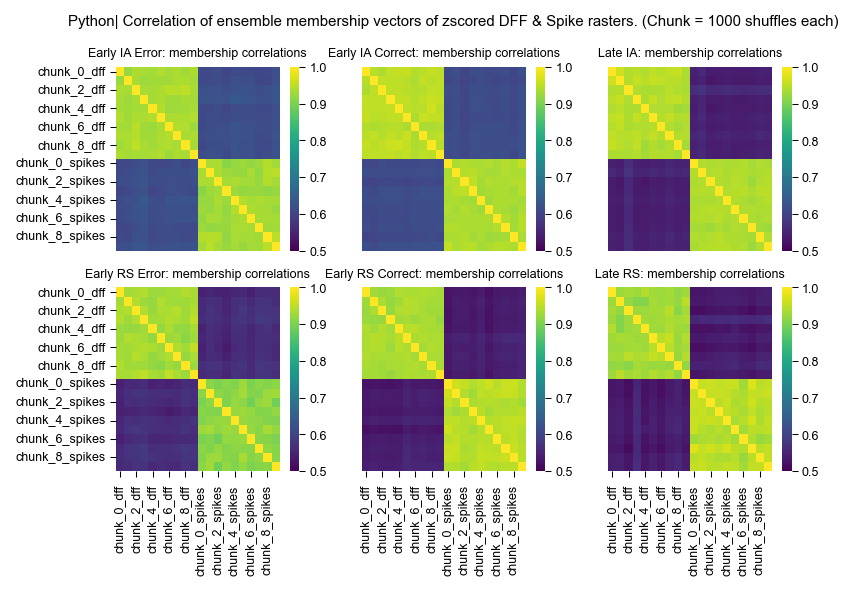

In [13]:

merged_enriched_chunks = pd.merge(enriched_by_chunk_dff, enriched_by_chunk_spikes, on=['subject_name', 'task_stage', 'cell'], suffixes=('_dff', '_spikes'))
# Plot correlation heatmaps
value_compared = "membership"
fig, axes = plt.subplots(2, 3, figsize=(6,3.5))
plot_stage_correlation_heatmaps(enrich_compared_df=merged_enriched_chunks, stage_names=stage_names, merge_chunk_col=[c for c in merged_enriched_chunks.columns if 'chunk_' in c], value_compared=value_compared, axes = axes)
fig.suptitle(f"Python| Correlation of ensemble {value_compared} vectors of zscored DFF & Spike rasters. (Chunk = 1000 shuffles each)")
# Save figure
fig_filename = f"dff_vs_spikes- ensemble_{value_compared}_vector_chunkcorrs.jpg"
fig.savefig(results_dir / fig_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved: {fig_filename} | In: {results_dir}")

Figure saved: dff_vs_ensembles_by_datatype['raster']emble_p-value_vector_chunkcorrs.jpg | In: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results


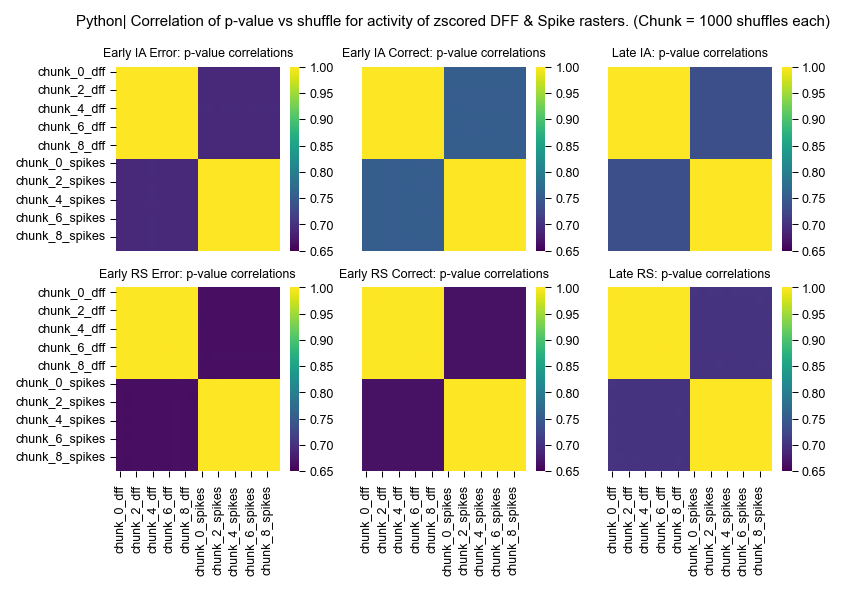

In [14]:
#use pvalue for corr 
pval_by_chunk_spikes = get_pivoted_enrichment_heatmap(all_chunk_ens_spikes, pivot_values = 'percent_shuffle >= real')
pval_by_chunk_dff = get_pivoted_enrichment_heatmap(all_chunk_ens_dff, pivot_values = 'percent_shuffle >= real')
merge_pval_chunks = pd.merge(pval_by_chunk_dff, pval_by_chunk_spikes, on=['subject_name', 'task_stage', 'cell'], suffixes=('_dff', '_spikes'))

# Plot correlation heatmaps
value_compared = "p-value"
fig, axes = plt.subplots(2, 3, figsize=(6,3.5))
plot_stage_correlation_heatmaps(enrich_compared_df=merge_pval_chunks, stage_names=stage_names, merge_chunk_col=[c for c in merge_pval_chunks.columns if 'chunk_' in c], value_compared=value_compared, vmin = 0.65, axes = axes)
fig.suptitle(f"Python| Correlation of {value_compared} vs shuffle for activity of zscored DFF & Spike rasters. (Chunk = 1000 shuffles each)")
# Save figure
fig_filename = f"dff_vs_ensembles_by_datatype['raster']emble_{value_compared}_vector_chunkcorrs.jpg"
fig.savefig(results_dir / fig_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved: {fig_filename} | In: {results_dir}")

#### import both DFF & spike ensemble parquets


In [15]:
#store both dff and spike ensembles dataframes in dict
ensembles_by_datatype, ensemble_table_by_datatype, ensemble_pvals_by_datatype = {}, {}, {}


In [16]:
# import DFF ensemble matrix- baseline Zscored
dff_ens_path = list(get_latest_shuffle_folder(results_dir, 'dff').parent.glob("*.parquet"))[0]
print(f"loading: {dff_ens_path}")
ensembles_by_datatype['dff'] = pd.read_parquet(dff_ens_path)
print(ensembles_by_datatype['dff'].info())
ensembles_by_datatype['dff'].tail(2)

loading: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_detection_07-Dec-2025_10000 shuffles\dff_postoutcome_python_ensembles_10000_shuff_07-Dec-2025_.parquet
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39534 entries, 0 to 39533
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   task_stage               39534 non-null  object 
 1   cell                     39534 non-null  object 
 2   percentile_95            39520 non-null  float64
 3   mean                     39520 non-null  float32
 4   enriched                 39534 non-null  bool   
 5   percent_shuffle >= real  39534 non-null  float64
 6   subject_name             39534 non-null  object 
 7   neuron_id                39534 non-null  object 
 8   date_made                39534 non-null  object 
 9   n_shuffles               39534 non-null  int64  
 10  data_type 

,task_stage,cell,percentile_95,mean,enriched,percent_shuffle >= real,subject_name,neuron_id,date_made,n_shuffles,data_type
39532,Late_RS,cell_215,0.726587,0.001032,False,0.3358,9_3_HET_RS3,9_3_HET_RS3-215,07-Dec-2025,10000,dff
39533,truncated_post_outcome,cell_215,0.174152,-0.165721,False,0.9979,9_3_HET_RS3,9_3_HET_RS3-215,07-Dec-2025,10000,dff


In [17]:
#import last spikes ensemble matrix for comparison #non normalized mean spike rate for the means 
raster_ensemble_path = list(get_latest_shuffle_folder(results_dir, 'raster').parent.glob("*.parquet"))[0]
print(f"Loading: {raster_ensemble_path}") # raster_ensemble_path = results_dir / Path(r"raster_none_norm_ensemble_detection_06-Dec-2025_5000 shuffles\raster_postoutcome_python_ensembles_5000_shuff_06-Dec-2025_.parquet")
ensembles_by_datatype['raster'] = pd.read_parquet(raster_ensemble_path)
print(ensembles_by_datatype['raster'].info())
ensembles_by_datatype['raster'].tail(2)

Loading: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\raster_none_norm_ensemble_detection_08-Dec-2025_10000 shuffles\raster_postoutcome_python_ensembles_10000_shuff_08-Dec-2025_.parquet
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38199 entries, 0 to 38198
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   task_stage               38199 non-null  object 
 1   cell                     38199 non-null  object 
 2   percentile_95            38199 non-null  float64
 3   mean                     38199 non-null  float64
 4   enriched                 38199 non-null  bool   
 5   percent_shuffle >= real  38199 non-null  float64
 6   subject_name             38199 non-null  object 
 7   neuron_id                38199 non-null  object 
 8   date_made                38199 non-null  object 
 9   n_shuffles               38199 non-null  int64  
 10  data_type      

,task_stage,cell,percentile_95,mean,enriched,percent_shuffle >= real,subject_name,neuron_id,date_made,n_shuffles,data_type
38197,Late_RS,cell_99,0.018333,0.000000,False,1.0000,9_3_HET_RS3,9_3_HET_RS3-99,08-Dec-2025,10000,raster
38198,truncated_post_outcome,cell_99,0.006127,0.002014,False,0.6078,9_3_HET_RS3,9_3_HET_RS3-99,08-Dec-2025,10000,raster


In [18]:
for d in data_types:
    #triage to only select real task stages (non-truncated)
    ensembles_by_datatype[d] = ensembles_by_datatype[d][ensembles_by_datatype[d].task_stage.isin(stage_names)]
    annotate_csv(ensembles_by_datatype[d], "subject_name")
    ensemble_table_by_datatype[d] = ensembles_by_datatype[d].pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = np.NaN).astype(float).assign(**{'data_type': d})
    if 'truncated_post_outcome' in ensembles_by_datatype[d].columns:
        print(f"dropping  'truncated_post_outcome' in ensemble_table_by_datatype[{d}]")
        ensemble_table_by_datatype[d] = ensemble_table_by_datatype[d].drop(columns = 'truncated_post_outcome')
    ensemble_pvals_by_datatype[d] = ensembles_by_datatype[d].pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'percent_shuffle >= real', fill_value = np.NaN).astype(float).assign(**{'data_type': d})
    

In [19]:
ensemble_table_by_datatype['raster']

task_stage,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,Late_IA,Late_RS,data_type
neuron_id,,,,,,,
10_3_HET_RS1-1,0.0,1.0,0.0,0.0,0.0,0.0,raster
10_3_HET_RS1-10,0.0,1.0,0.0,0.0,0.0,0.0,raster
10_3_HET_RS1-100,0.0,0.0,0.0,0.0,0.0,0.0,raster
10_3_HET_RS1-101,0.0,0.0,0.0,0.0,0.0,0.0,raster
10_3_HET_RS1-102,0.0,0.0,0.0,0.0,0.0,0.0,raster
...,...,...,...,...,...,...,...
9_3_HET_RS3-95,0.0,1.0,0.0,0.0,0.0,0.0,raster
9_3_HET_RS3-96,0.0,0.0,0.0,0.0,0.0,0.0,raster
9_3_HET_RS3-97,0.0,0.0,0.0,0.0,0.0,0.0,raster


#### Analysis: Compare ensemble pvalue & enrichment between zscored dff & spike raster

In [20]:
## merge both enrichment vectors for comparison 
raster_dff_ens_vecs = ensemble_table_by_datatype['raster'].merge(ensemble_table_by_datatype['dff'], on = 'neuron_id', suffixes=('_spikes', '_dff'))
raster_dff_ens_corr_df = get_intercol_corrs(raster_dff_ens_vecs, stage_names, suffix1="_spikes", suffix2="_dff")

## merge both spike + dff pvalue matrices
raster_dff_ens_pvals =  ensemble_pvals_by_datatype['raster'].merge(ensemble_pvals_by_datatype['dff'], on = 'neuron_id', suffixes=('_spikes', '_dff'))
ens_pval_corr_df = get_intercol_corrs(raster_dff_ens_pvals, stage_names, suffix1="_spikes", suffix2="_dff")

## print summary:
print(f" Correlation of ensemble enrichment (vs. shuffle), between z-scored df/F data & spike rasters \n{raster_dff_ens_corr_df}")
print(f" Correlation of ensemble activity p-value (vs. shuffle), between z-scored df/F data & spike rasters: \n{ens_pval_corr_df}")

 Correlation of ensemble enrichment (vs. shuffle), between z-scored df/F data & spike rasters 
                  Correlation
Early_IA_Error       0.624613
Early_IA_Correct     0.614595
Late_IA              0.550077
Early_RS_Error       0.574041
Early_RS_Correct     0.525900
Late_RS              0.535796
 Correlation of ensemble activity p-value (vs. shuffle), between z-scored df/F data & spike rasters: 
                  Correlation
Early_IA_Error       0.689938
Early_IA_Correct     0.753088
Late_IA              0.734657
Early_RS_Error       0.663554
Early_RS_Correct     0.666088
Late_RS              0.702068


#### Threshold time-series df to remove 0 

In [21]:
#for concordance with previous code, need to label the stage col as 'task_stage_vec
stage_col = 'task_phase_vec'

def normalize_tseries_df(trial_tseries_df_raw: pd.DataFrame,
                          n_end_timebins_to_drop = config['timeseries']['n_end_timebins_to_drop'], #default = 0,
                          n_start_timebins_to_drop = config['timeseries']['n_start_timebins_to_drop'], #default = 8,
                          name_col: str = 'subject_name',
                          neuron_id_col: str = 'neuron_id',
                          ) -> pd.DataFrame:
    """ Normalize trial time-series DataFrame based on normalization type.
    Inputs:
    trial_tseries_df_raw : DataFrame with raw time-series data (ALREADY BINNED)
    hyper_param_dict : dictionary of hyperparameters
    outcome_post : DataFrame with outcome post data

    Returns: Normalized trial time-series DataFrame
    """
    #get normalization info for curr df
    normed = trial_tseries_df_raw['normalized'].unique()[0]
    if normed == 'none':
        use_min_max_norm = True 
    else:
        use_min_max_norm = False
    print(f" Data Normalization type: {normed} | Applying min-max norm? {use_min_max_norm} ")
    numeric_col = get_numeric_cols_timeseries(trial_tseries_df_raw, " to ") 
    #OPTIONAL- drop N bins from start and M bins from end of time-series
    #first, check if you're pre-truncated the data (e.g. already only sliced 3 seconds before outcome)
    neg_timebins = [c for c in numeric_col if "-" in c]
    if len(neg_timebins) <4*3+1: #if you only have 1 second or so of pre-outcome data, you've already sliced 
        n_start_timebins_to_drop = 0
    trial_tseries_df_norm = drop_end_bins_of_trials(trial_tseries_df_raw,numeric_col,  n_end_timebins_to_drop = n_end_timebins_to_drop )
    trial_tseries_df_norm = drop_start_bins_of_trials(trial_tseries_df_norm,numeric_col,  n_start_timebins_to_drop =n_start_timebins_to_drop)
    
    # # 12/9/25- move min max norm to AFTER bin dropping, so you're not using max value from dropped frames
    numeric_col = get_numeric_cols_timeseries(trial_tseries_df_norm, " to ") 
    trial_tseries_df_norm = run_min_max_norm_on_timeseries(use_min_max_norm,trial_tseries_df_norm, [name_col, neuron_id_col], numeric_col, 'max_trial_val') #min_max_norm = True
    #get mean of each trial- IS this run BEFORE or AFTER norm? 
    #get mean of each trial
    cols_to_get_mean = [c for c in numeric_col]    
    trial_tseries_df_norm['mean_rate'] =trial_tseries_df_norm[cols_to_get_mean].mean(axis = 1) #mean rate is post outcome only
    trial_tseries_df_norm['active_in_trial'] =trial_tseries_df_norm['mean_rate']>0

    return trial_tseries_df_norm

def normalize_all_subject_tseries_dfs(raster_base_dfs: Dict[str, pd.DataFrame],
                                      data_type = 'raster', # selects what enrichment ensemble to pull from: 
                                      ensemble_by_datatype_dict= None,
                                      config = config, 
                                      n_end_timebins_to_drop = 0,
                                      n_start_timebins_to_drop = 8,
                                      name_col: str = 'subject_name',
                                      neuron_id_col: str = 'neuron_id',
                                      ) -> pd.DataFrame:
    """ Normalize all subject trial time-series DataFrames.
    Inputs:     raster_base_dfs : Dict of subject_name to raw full recording matrix DataFrame
    optional settings for time-series normalization that equal defaults, so left un input
    Returns: concat. dataframe of subject_name to normalized trial time-series DataFrame
    """

    raster_timeseries =[]
    for name, raster_df in raster_base_dfs.items():
        print(f" Reshaping tseries of {name}: {raster_df.shape}")    
        subj_trial_tseries_df_raw= create_subject_trial_tseries_df(raster_df, ensemble_by_datatype_dict[data_type].loc[:, stage_names], config = config)
        numeric_col = get_numeric_cols_timeseries(subj_trial_tseries_df_raw, " to ") 

        print([c for c in subj_trial_tseries_df_raw.columns if c not in numeric_col])
        subj_trial_tseries_df_norm= normalize_tseries_df(subj_trial_tseries_df_raw)
        raster_timeseries.append(subj_trial_tseries_df_norm)
    trial_tseries_df_norm = pd.concat(raster_timeseries)
    return trial_tseries_df_norm
#1) create_subject_trial_tseries_df
    # -
# 2) normalize_tseries_df
# 2a- run_min_max_norm_on_timeseries ADDS max_trial_val

In [22]:
trial_tseries_df_norm = normalize_all_subject_tseries_dfs(raster_dataframes_spikes, data_type = 'raster',  ensemble_by_datatype_dict=ensemble_table_by_datatype, config = config)
trial_tseries_df_norm.head()


 Reshaping tseries of 10_3_HET_RS1: (135487, 132)
Using 0 pre-outcome frames
binning data- post. # post-outcome frames: 300 #pre-outcome frames: 101
rem_frames: 1
Merge penultimate/last bin with only 1 frame in it, then dropping last bin
 Moving numeric coluns by 0 bins
['trial_num', 'cell', 'subject_name', 'session', 'geno', 'task_phase_vec', 'normalized', 'datatype', 'neuron_id', 'day', 'geno_day', 'Early_IA_Error', 'Early_IA_Correct', 'Late_IA', 'Early_RS_Error', 'Early_RS_Correct', 'Late_RS', 'any_enrichment', 'enriched_in_phase']
 Data Normalization type: none | Applying min-max norm? True 
Dropping 0 bins from end: []
Dropping 8 bins from start: Index(['-5.0s to -4.75s', '-4.75s to -4.5s', '-4.5s to -4.25s',
       '-4.25s to -4.0s', '-4.0s to -3.75s', '-3.75s to -3.5s',
       '-3.5s to -3.25s', '-3.25s to -3.0s'],
      dtype='object')
 Reshaping tseries of 10_3_HET_RS2: (85240, 162)
Using 0 pre-outcome frames
binning data- post. # post-outcome frames: 300 #pre-outcome frames: 

,trial_num,cell,subject_name,session,geno,task_phase_vec,normalized,datatype,neuron_id,day,...,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS,any_enrichment,enriched_in_phase,max_trial_val,mean_rate,active_in_trial
0,1,cell_1,10_3_HET_RS1,RS1,HET,Early_IA_Correct,none,raster,10_3_HET_RS1-1,1,...,0.0,0.0,0.0,0.0,0.0,1.0,False,1.0,0.0,False
1,1,cell_10,10_3_HET_RS1,RS1,HET,Early_IA_Correct,none,raster,10_3_HET_RS1-10,1,...,0.0,0.0,0.0,0.0,0.0,1.0,False,1.0,0.0,False
3,1,cell_101,10_3_HET_RS1,RS1,HET,Early_IA_Correct,none,raster,10_3_HET_RS1-101,1,...,0.0,0.0,0.0,0.0,0.0,0.0,False,1.0,0.0,False
5,1,cell_104,10_3_HET_RS1,RS1,HET,Early_IA_Correct,none,raster,10_3_HET_RS1-104,1,...,1.0,1.0,1.0,0.0,0.0,3.0,True,1.0,0.0,False
8,1,cell_107,10_3_HET_RS1,RS1,HET,Early_IA_Correct,none,raster,10_3_HET_RS1-107,1,...,0.0,0.0,0.0,0.0,0.0,0.0,False,1.0,0.0,False


In [23]:
trial_tseries_df_norm.max_trial_val.value_counts()

max_trial_val
1.0    86947
0.8     2621
0.6     1706
0.4      334
0.2      119
0.7       79
0.5       59
0.9       20
Name: count, dtype: int64

In [24]:

#save filename with data type and date info
single_trial_timeseries_dir =  results_dir / Path(r"python_output_single_trial_timeseries")
single_trial_timeseries_dir.mkdir(parents=True, exist_ok=True)
save_name = single_trial_timeseries_dir / Path(f"python-made_trial_timeseries_{data_type_used}_{datetime.now().strftime("%Y-%m-%d %H")}.parquet")
print(f"saving file as {save_name}")
trial_tseries_df_norm.to_parquet(save_name)

# get mean time-series value
numeric_col = get_numeric_cols_timeseries(trial_tseries_df_norm, " to ")  #update post drop
unit_mean_tseries =  get_unit_mean_timeseries_by_phase(trial_tseries_df_norm,['trial_num'], ['subject_name', 'neuron_id','geno_day', stage_col], numeric_col) 
print(f"{unit_mean_tseries.groupby(by = 'geno_day')['neuron_id'].nunique().sum()} total units:")
unit_mean_tseries.tail(3)


saving file as C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\python_output_single_trial_timeseries\python-made_trial_timeseries_raster_2025-12-12 10.parquet
4706 total units:


,subject_name,neuron_id,geno_day,task_phase_vec,-3.0s to -2.75s,-2.75s to -2.5s,-2.5s to -2.25s,-2.25s to -2.0s,-2.0s to -1.75s,-1.75s to -1.5s,...,Early_RS_Error,Early_RS_Correct,Late_RS,any_enrichment,enriched_in_phase,max_trial_val,mean_rate,active_in_trial,max_val,max_val_tbin
27358,9_3_HET_RS3,9_3_HET_RS3-99,Het postCLNZ,Early_RS_Error,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,False,1.0,0.000000,False,0.0,-3.0s to -2.75s
27359,9_3_HET_RS3,9_3_HET_RS3-99,Het postCLNZ,Late_IA,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,False,1.0,0.009333,True,0.2,4.0s to 4.25s
27360,9_3_HET_RS3,9_3_HET_RS3-99,Het postCLNZ,Late_RS,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,False,1.0,0.000000,False,0.0,-3.0s to -2.75s


In [25]:
mean_activity_val = unit_mean_tseries.pivot_table(index = ['neuron_id'], columns = 'task_phase_vec', values = 'mean_rate', fill_value = np.nan).astype(float).sum(axis = 1)
zero_mean_cells = mean_activity_val[mean_activity_val == 0].index.values
print(len(zero_mean_cells))
print(zero_mean_cells)

82
['10_3_HET_RS1-35' '10_3_HET_RS1-66' '10_3_HET_RS2-2' '13_3_HET_RS1-101'
 '13_3_HET_RS1-121' '13_3_HET_RS1-158' '13_3_HET_RS1-26'
 '13_3_HET_RS2-133' '13_4_WT_RS1-157' '13_4_WT_RS1-168' '13_4_WT_RS1-172'
 '13_4_WT_RS1-83' '13_4_WT_RS1-98' '13_4_WT_RS2-126' '13_5_HET_RS1-104'
 '13_5_HET_RS2-102' '13_5_HET_RS2-78' '13_5_HET_RS2-89' '13_5_HET_RS3-103'
 '13_6_WT_RS1-111' '13_6_WT_RS1-113' '13_6_WT_RS1-114' '13_6_WT_RS1-120'
 '13_6_WT_RS1-123' '13_6_WT_RS1-127' '13_6_WT_RS1-136' '13_6_WT_RS1-146'
 '13_6_WT_RS1-148' '13_6_WT_RS1-177' '13_6_WT_RS1-62' '13_6_WT_RS2-118'
 '13_6_WT_RS2-170' '13_8_HET_RS1-131' '13_8_HET_RS2-111'
 '13_8_HET_RS2-197' '13_8_HET_RS2-202' '13_8_HET_RS2-29' '13_8_HET_RS2-5'
 '13_8_HET_RS2-98' '13_8_HET_RS3-129' '13_8_HET_RS3-145'
 '13_8_HET_RS3-235' '13_8_HET_RS3-50' '13_8_HET_RS3-89' '13_8_HET_RS3-95'
 '14_2_WT_RS1-102' '14_2_WT_RS1-120' '14_2_WT_RS1-52' '14_2_WT_RS1-90'
 '14_2_WT_RS2-100' '14_2_WT_RS2-21' '14_2_WT_RS2-5' '15_1_HET_RS1-137'
 '15_1_HET_RS1-59' '15_1

Text(0.5, 1.0, 'Activity of cells with 0 mean event rate during post-outcome')

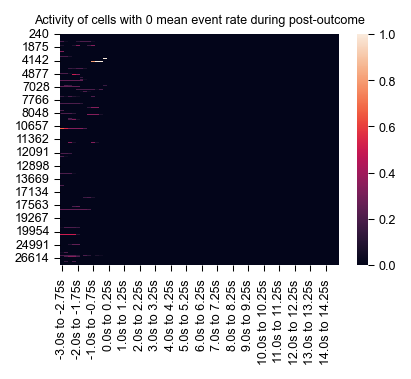

In [26]:
fig, ax = plt.subplots(1,1, figsize = (3,2))
sns.heatmap(unit_mean_tseries.loc[(unit_mean_tseries.neuron_id.isin(zero_mean_cells)), numeric_col])
ax.set_title(f"Activity of cells with 0 mean event rate during post-outcome")

#### Import canon ensemble + tseries to compare umap

In [27]:
# import canonical ensemble matrix previously created in MATLAB, used for paper #find old file- 
canonical_file = data_dir / Path(r"Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet")
canonical_data = pd.read_parquet(canonical_file) #normalized spike rates for the means 

#get canon mean unit timeseries
numeric_col_canon = get_numeric_cols_timeseries(canonical_data, " to ")  #update post drop\
canon_mean_unit_tseries  =  get_unit_mean_timeseries_by_phase(canonical_data,['trial_num'], ['name', 'neuron_ID','geno_day', stage_col], numeric_col_canon) 
canon_mean_unit_tseries.tail(3)


,name,neuron_ID,geno_day,task_phase_vec,-3.0s to -2.75s,-2.75s to -2.5s,-2.5s to -2.25s,-2.25s to -2.0s,-2.0s to -1.75s,-1.75s to -1.5s,...,Early_RS_Correct,Late_RS,enriched_in_phase,any_enrichment,unique_ID,max_trial_val,mean_rate,active_in_trial,max_val,max_val_tbin
27765,9_3_HET_RS3,215,Het postCLNZ,Early_RS_Error,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,0.0,9_3_HET_RS3-215,0.8,0.000000,False,0.0000,-3.0s to -2.75s
27766,9_3_HET_RS3,215,Het postCLNZ,Late_IA,0.05,0.00,0.2,0.0,0.2,0.0500,...,0.0,0.0,False,0.0,9_3_HET_RS3-215,0.8,0.000000,False,0.2000,-2.5s to -2.25s
27767,9_3_HET_RS3,215,Het postCLNZ,Late_RS,0.00,0.25,0.0,0.0,0.0,0.0625,...,0.0,0.0,False,0.0,9_3_HET_RS3-215,0.8,0.021875,False,0.3125,1.25s to 1.5s


#### UMAP on enrichment matrices

In [28]:

# # Determine first active stage for each neuron
def get_first_active_stage(row, stage_order,  non_enriched_label = 'Never'):
    """Find the first stage where neuron is enriched (value = 1)"""
    for stage in stage_order:
        if stage in row.index and row[stage] == 1:
            return stage
    return non_enriched_label

def run_dimensionality_reduction(ensemble_matrix, method='umap', metric='cosine', random_state=42, **method_kwargs):
    """Run UMAP or t-SNE on ensemble matrix. Returns (df, model)."""
    from sklearn.manifold import TSNE
    import umap
    import pandas as pd
    complete_data = ensemble_matrix.dropna()
    # print(f"Shape: {ensemble_matrix.shape} → {complete_data.shape}")
    
    if method.lower() == 'umap':
        model = umap.UMAP(n_neighbors=method_kwargs.get('n_neighbors', 15), min_dist=method_kwargs.get('min_dist', 0.1), 
                          metric=metric, random_state=random_state)
    elif method.lower() == 'tsne':
        model = TSNE(perplexity=method_kwargs.get('perplexity', 30), learning_rate=method_kwargs.get('learning_rate', 200), max_iter=method_kwargs.get('max_iter', 1000),
            metric=metric, method= 'exact', early_exaggeration = method_kwargs.get('early_exaggeration', 12),
            random_state=random_state)
    else:
        raise ValueError(f"method must be 'umap' or 'tsne', got '{method}'")
    
    embedding = model.fit_transform(complete_data)
    results_df = pd.DataFrame({'dim1': embedding[:, 0], 'dim2': embedding[:, 1], 'method': method.upper()}, index=complete_data.index)
    return results_df, model

In [29]:
def get_lowD_matrix_w_ensemble_info(ensemble_df,
                                    value_col='mean', 
                                    method='tsne', 
                                    method_params=None,
                                    stage_order=None, 
                                    verbose=True,
                                    enriched_bool_col_name = 'enriched', 
                                    task_stage_col_name = 'task_stage',
                                    neuron_ID_col_name = 'neuron_id'):
    """Project ensemble activity to low-d space with enrichment metadata."""
    # Pivot and clean
    input_df = ensemble_df.pivot_table(index=neuron_ID_col_name,
                                        columns=task_stage_col_name,
                                          values=value_col).replace([np.inf, -np.inf], np.nan).dropna()
    input_df = input_df[input_df.sum(axis=1) > 0]
    
    if verbose:
        print(f" {input_df.shape[0]} cells after filtering")
    
    proj_df, model = run_dimensionality_reduction(input_df, method=method, **(method_params or {}))
    
    # Add first_active_stage if stage_order provided
    if stage_order:
        first_active = (ensemble_df.pivot_table(index=neuron_ID_col_name, columns=task_stage_col_name, values=enriched_bool_col_name).apply(get_first_active_stage, axis=1, stage_order=stage_order))
        proj_df = proj_df.join(first_active.rename('first_active_stage'))
    
    return proj_df, model, input_df


In [30]:
canon_mean_unit_tseries.tail()

,name,neuron_ID,geno_day,task_phase_vec,-3.0s to -2.75s,-2.75s to -2.5s,-2.5s to -2.25s,-2.25s to -2.0s,-2.0s to -1.75s,-1.75s to -1.5s,...,Early_RS_Correct,Late_RS,enriched_in_phase,any_enrichment,unique_ID,max_trial_val,mean_rate,active_in_trial,max_val,max_val_tbin
27763,9_3_HET_RS3,215,Het postCLNZ,Early_IA_Error,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,0.0,9_3_HET_RS3-215,0.8,0.000000,False,0.0000,-3.0s to -2.75s
27764,9_3_HET_RS3,215,Het postCLNZ,Early_RS_Correct,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,0.0,9_3_HET_RS3-215,0.8,0.000000,False,0.0000,-3.0s to -2.75s
27765,9_3_HET_RS3,215,Het postCLNZ,Early_RS_Error,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,0.0,9_3_HET_RS3-215,0.8,0.000000,False,0.0000,-3.0s to -2.75s
27766,9_3_HET_RS3,215,Het postCLNZ,Late_IA,0.05,0.00,0.2,0.0,0.2,0.0500,...,0.0,0.0,False,0.0,9_3_HET_RS3-215,0.8,0.000000,False,0.2000,-2.5s to -2.25s
27767,9_3_HET_RS3,215,Het postCLNZ,Late_RS,0.00,0.25,0.0,0.0,0.0,0.0625,...,0.0,0.0,False,0.0,9_3_HET_RS3-215,0.8,0.021875,False,0.3125,1.25s to 1.5s


In [31]:
#set umap params
value_to_project = 'mean'
metric = 'cosine'
method = 'tsne'
method_dict = {'tsne': {'n_components': 2, "perplexity": 90, "learning_rate": 'auto',  'init':'pca','early_exaggeration': 12, 'random_state':42},
               'umap': dict(n_neighbors=10, min_dist=0.25, metric=metric,random_state=42)}
#import canon timeseries + taco, #make pivot of mean activity of cell over its timeseries 
annotate_csv(canon_mean_unit_tseries, 'name') # canon_spike_umap_input = canon_mean_unit_tseries.pivot_table(index = ['unique_ID', 'name'], columns = 'task_phase_vec', values = 'mean_rate', fill_value = np.nan).reset_index(level=1)

plot_types = data_types + ["canon_raster"]

#package spikes + dff for umap processing 
umap_input, umap_projection_df, umap_model = {}, {}, {}
for d in plot_types:
    umap_input[d], umap_projection_df[d], umap_model[d] = {}, {}, {} #to allow geno-day subset
    
    for g in geno_order_w_WT_CLNZ:
        print(f"Projecting {d}- {g}")        #filter out genotype-day group
        if d == 'canon_raster':
            umap_projection_df[d][g], umap_model[d][g],umap_input[d][g] = get_lowD_matrix_w_ensemble_info(canon_mean_unit_tseries.loc[canon_mean_unit_tseries.geno_day == g,:],
                                                                                                        value_col='mean_rate', 
                                                                                                        method= method,
                                                                                                        method_params=method_dict[method],
                                                                                                        stage_order=stage_names,
                                                                                                        enriched_bool_col_name = 'enriched_in_phase',
                                                                                                        task_stage_col_name = "task_phase_vec",
                                                                                                        neuron_ID_col_name = 'unique_ID')
        else: 
            ensemble_geno_day_df =ensembles_by_datatype[d].loc[ensembles_by_datatype[d].geno_day == g,:]
            umap_projection_df[d][g], umap_model[d][g],umap_input[d][g] = get_lowD_matrix_w_ensemble_info(ensemble_geno_day_df,
                                                                                                        value_col='mean', 
                                                                                                        method= method,
                                                                                                        method_params=method_dict[method],
                                                                                                        stage_order=stage_names)
            
    #after all genos ran, concat, retaining information on geno-day
    umap_projection_df[d] = pd.concat([df.assign(**{'geno': geno}) for geno, df in umap_projection_df[d].items()])


Projecting raster- WT VEH
 848 cells after filtering
Projecting raster- WT CLNZ
 833 cells after filtering
Projecting raster- Het VEH
 746 cells after filtering
Projecting raster- Het CLNZ
 752 cells after filtering
Projecting raster- Het postCLNZ
 686 cells after filtering
Projecting dff- WT VEH
 417 cells after filtering
Projecting dff- WT CLNZ
 413 cells after filtering
Projecting dff- Het VEH
 397 cells after filtering
Projecting dff- Het CLNZ
 411 cells after filtering
Projecting dff- Het postCLNZ
 311 cells after filtering
Projecting canon_raster- WT VEH
 845 cells after filtering
Projecting canon_raster- WT CLNZ
 818 cells after filtering
Projecting canon_raster- Het VEH
 727 cells after filtering
Projecting canon_raster- Het CLNZ
 723 cells after filtering
Projecting canon_raster- Het postCLNZ
 672 cells after filtering


#### NEW- project by genotype into UMAP space

0 raster
0 WT VEH
1 WT CLNZ
2 Het VEH
3 Het CLNZ
4 Het postCLNZ
1 dff
0 WT VEH
1 WT CLNZ
2 Het VEH
3 Het CLNZ
4 Het postCLNZ
2 canon_raster
0 WT VEH
1 WT CLNZ
2 Het VEH
3 Het CLNZ
4 Het postCLNZ


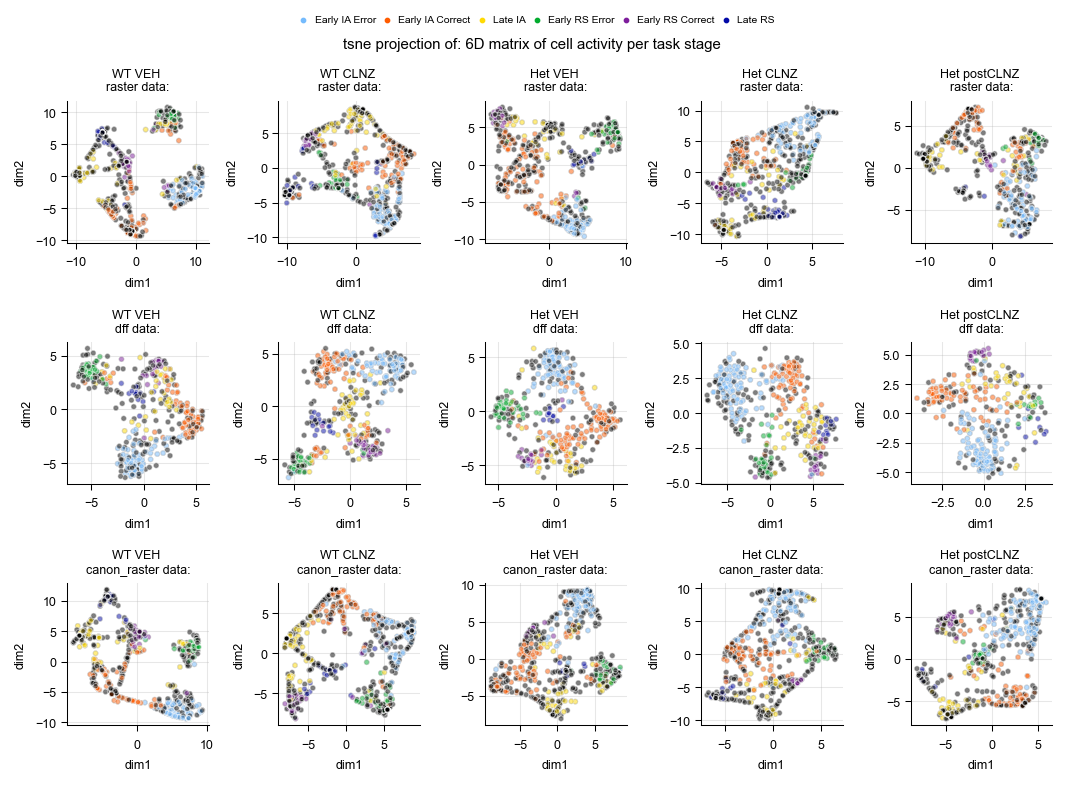

In [32]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn')

#sne settings: NON ENRICHED:  s = 5,alpha = 0.35, linewidth =0.5, legend = False, palette = ['black'],  zorder=0
#ENRICHED: s = 6,alpha = 0.5, legend = make_legend, palette = [stage_palette_dict[x] for x in stage_chrono_order], hue_order =stage_chrono_order,zorder=100 )
alpha = 0.5
s_base = 6
genos_to_plot = geno_order_w_WT_CLNZ
row_types = plot_types #['dff', 'raster']
## PLOTTING- note that paper tSNE is projection of mean activity in stage, colored by ensemble identity
n_rows = len(row_types)
n_cols = len(genos_to_plot)

fig, ax_array = plt.subplots(n_rows, n_cols, figsize=(7, 5), layout = 'constrained')
fig.suptitle(f"{method} projection of: 6D matrix of cell activity per task stage ")
palette = [stage_palette_dict[x] for x in stage_names]
hue_order = stage_names 
hue_col = 'first_active_stage'

debug_max_vals = []
for r, row_type in enumerate(row_types):
    print(r,row_type)
    row_data = umap_projection_df[row_type]
    for c, geno in enumerate(genos_to_plot):
        print(c,geno)
        make_legend = (r == 0) & (c == 0)
        ax = ax_array[r,c]
        ax_data = data=row_data.loc[row_data.geno == geno,:]
        #plot NONenriched first
        sns.scatterplot(ax=ax, data=ax_data, x='dim1', y='dim2',  hue=hue_col, palette=['black'], hue_order=['Never'] , s=5, alpha=0.35, linewidth=0.5, legend=False, zorder = 0)
        # set non enriched cell facecolor to 0
        #find collections with > 1 point contained therein
        nonlegend_collections = [x for x in ax.collections if x.get_facecolors().shape[0]>1]
        collection_size= [x.get_facecolors().shape for x in nonlegend_collections]
        largest_collection_size = np.max(collection_size) #use largest collection as == ensemble 
        non_enrich_collection = [x for x in nonlegend_collections if x.get_facecolors().shape[0] == largest_collection_size][0]
        non_enrich_collection.set_edgecolors(non_enrich_collection.get_facecolors().copy())# Restore the edge colors using the saved values
        non_enrich_collection.set_facecolors("none")# Remove the face color by setting it to "none"
        #plot enriched
        sns.scatterplot(ax=ax, data=ax_data, x='dim1', y='dim2', hue=hue_col, palette=palette, hue_order=hue_order , s=s_base, alpha=alpha, linewidth=0.5, legend=make_legend, zorder = 100)
        #layout changes
        ax.set_title(f'{geno} \n{row_type} data:')
        ax.grid(True, alpha=0.3)
        ax.set_box_aspect(1)
    #get legend and move

hand, labels = ax_array.flat[0].get_legend_handles_labels()
ax_array.flat[0].get_legend().remove()
fig.legend(hand, [x.replace('_', ' ') for x in labels], bbox_to_anchor=(0.5, 1),loc = 'lower center', ncol = 7, frameon = False, title = None, handletextpad=0.1, );
fig.savefig(results_dir / Path(f"tsne_projection_dff_raster_canon.png"))


#### new- UMAP parameter sweep to see viz

In [34]:
from sklearn.metrics import silhouette_score
from sklearn.manifold import trustworthiness
from itertools import product

#set params
g = "WT VEH"
d = "raster"
value_to_project = 'mean'
metric = 'cosine'
method = 'tsne'
# Define sweep
sweep_params = {'umap': {'n_neighbors': [5, 10, 15, 30, 50], 'min_dist': [0.0, 0.1, 0.25, 0.5]},
                'tsne': {'perplexity': [15, 30, 50, 90, 100], 'learning_rate': ['auto', 200, 500]}}

# method_dict = {'tsne': {'n_components': 2, "perplexity": 90,  'init':'pca', 'random_state':42}, 'umap': dict(n_neighbors=15, min_dist=0.2, metric=metric,random_state=42)}
test_df =ensembles_by_datatype['raster'].query(f'geno_day ==  "WT VEH"')
test_df


,task_stage,cell,percentile_95,mean,enriched,percent_shuffle >= real,subject_name,neuron_id,date_made,n_shuffles,data_type,day,geno,geno_day
5478,Early_IA_Correct,cell_1,0.122222,0.025556,False,0.4366,13_4_WT_RS1,13_4_WT_RS1-1,08-Dec-2025,10000,raster,1,WT,WT VEH
5479,Early_IA_Error,cell_1,0.135000,0.125000,False,0.0583,13_4_WT_RS1,13_4_WT_RS1-1,08-Dec-2025,10000,raster,1,WT,WT VEH
5480,Early_RS_Correct,cell_1,0.098333,0.030000,False,0.4848,13_4_WT_RS1,13_4_WT_RS1-1,08-Dec-2025,10000,raster,1,WT,WT VEH
5481,Early_RS_Error,cell_1,0.186667,0.000000,False,1.0000,13_4_WT_RS1,13_4_WT_RS1-1,08-Dec-2025,10000,raster,1,WT,WT VEH
5482,Late_IA,cell_1,0.091333,0.000000,False,1.0000,13_4_WT_RS1,13_4_WT_RS1-1,08-Dec-2025,10000,raster,1,WT,WT VEH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30756,Early_IA_Error,cell_99,0.121750,0.000000,False,1.0000,7_5_WT_RS1,7_5_WT_RS1-99,08-Dec-2025,10000,raster,1,WT,WT VEH
30757,Early_RS_Correct,cell_99,0.115556,0.056667,False,0.1955,7_5_WT_RS1,7_5_WT_RS1-99,08-Dec-2025,10000,raster,1,WT,WT VEH
30758,Early_RS_Error,cell_99,0.115000,0.000000,False,1.0000,7_5_WT_RS1,7_5_WT_RS1-99,08-Dec-2025,10000,raster,1,WT,WT VEH
30759,Late_IA,cell_99,0.083333,0.078000,False,0.0650,7_5_WT_RS1,7_5_WT_RS1-99,08-Dec-2025,10000,raster,1,WT,WT VEH


In [35]:
def run_param_sweep(ensemble_df, stage_order, sweep_test_method, sweep_config, value_col='mean', verbose=True):
    """ Sweep dimensionality reduction parameters and log quality metrics. Returns DataFrame with columns: method, params, silhouette, trustworthiness """
    print(f"Testing {sweep_test_method}")
    results = []
    param_grid = sweep_config[sweep_test_method] #use user input method string to index into what params to sweep over


    keys, values = zip(*param_grid.items())
    for combo in product(*values):
        params = dict(zip(keys, combo))
        params['random_state'] = 42
        print(f"{sweep_test_method}: {params}")
        
        proj_df, _, input_df = get_lowD_matrix_w_ensemble_info(ensemble_df, value_col=value_col, 
                                                               method= sweep_test_method,
                                                               method_params= params, stage_order= stage_order, verbose=False)
        
        # Metrics
        coords = proj_df[['dim1', 'dim2']].values
        labels = proj_df['first_active_stage']
        # calc metrics
        # Silhouette in original space (before projection)
        high_d_sil = round(silhouette_score(input_df.values, labels),4)
        # print(f"High-D silhouette: {high_d_sil}")
        sil = round(silhouette_score(coords, labels),4) if labels.nunique() > 1 else np.nan
        
        if method == 'umap':
          k = params.get('n_neighbors', 15)
        elif method == 'tsne':
          k = int(params.get('perplexity', 30))  # perplexity ≈ effective neighbors
        trust = round(trustworthiness(input_df.values, coords, n_neighbors=k, metric = 'cosine'),4)
        results.append({'method': sweep_test_method, 
                        'silhouette': sil,
                        'high_d_sil': high_d_sil,
                        f'trust': trust,
                        'trust_k': k,
                        **params})

    return pd.DataFrame(results)

In [36]:
#run and save t-sne parameter sweep
sweep_results = run_param_sweep(test_df, stage_names, sweep_test_method = method, sweep_config =  sweep_params)
sweep_filename = Path(f"tsne_param_sweep_results_on_WT_VEH_{datetime.now().strftime("%Y-%m-%d %H")}.csv")
sweep_results.to_csv(results_dir / sweep_filename)
sweep_results

Testing tsne
tsne: {'perplexity': 15, 'learning_rate': 'auto', 'random_state': 42}
tsne: {'perplexity': 15, 'learning_rate': 200, 'random_state': 42}
tsne: {'perplexity': 15, 'learning_rate': 500, 'random_state': 42}
tsne: {'perplexity': 30, 'learning_rate': 'auto', 'random_state': 42}
tsne: {'perplexity': 30, 'learning_rate': 200, 'random_state': 42}
tsne: {'perplexity': 30, 'learning_rate': 500, 'random_state': 42}
tsne: {'perplexity': 50, 'learning_rate': 'auto', 'random_state': 42}
tsne: {'perplexity': 50, 'learning_rate': 200, 'random_state': 42}
tsne: {'perplexity': 50, 'learning_rate': 500, 'random_state': 42}
tsne: {'perplexity': 90, 'learning_rate': 'auto', 'random_state': 42}
tsne: {'perplexity': 90, 'learning_rate': 200, 'random_state': 42}
tsne: {'perplexity': 90, 'learning_rate': 500, 'random_state': 42}
tsne: {'perplexity': 100, 'learning_rate': 'auto', 'random_state': 42}
tsne: {'perplexity': 100, 'learning_rate': 200, 'random_state': 42}
tsne: {'perplexity': 100, 'learn

,method,silhouette,high_d_sil,trust,trust_k,perplexity,learning_rate,random_state
0,tsne,-0.2760,0.1677,0.9839,15,15,auto,42
1,tsne,-0.2466,0.1677,0.9844,15,15,200,42
2,tsne,-0.2705,0.1677,0.9851,15,15,500,42
3,tsne,-0.2572,0.1677,0.9801,30,30,auto,42
4,tsne,-0.2519,0.1677,0.9801,30,30,200,42
5,tsne,-0.2684,0.1677,0.9809,30,30,500,42
6,tsne,-0.2608,0.1677,0.9800,50,50,auto,42
7,tsne,-0.2730,0.1677,0.9781,50,50,200,42
8,tsne,-0.2816,0.1677,0.9772,50,50,500,42
9,tsne,-0.2650,0.1677,0.9789,90,90,auto,42


In [37]:
sweep_params

{'umap': {'n_neighbors': [5, 10, 15, 30, 50],
  'min_dist': [0.0, 0.1, 0.25, 0.5]},
 'tsne': {'perplexity': [15, 30, 50, 90, 100],
  'learning_rate': ['auto', 200, 500]}}

In [38]:
# param_grid = sweep_config[sweep_test_method] #use user input method string to index into what params to sweep over
#     keys, values = zip(*param_grid.items())
#     for combo in product(*values):
#         params = dict(zip(keys, combo))
#         params['random_state'] = 42
#         print(f"{sweep_test_method}: {params}")
        
#         proj_df, _, input_df = get_lowD_matrix_w_ensemble_info(ensemble_df, value_col=value_col, method= sweep_test_method, method_params= params, stage_order= stage_order, verbose=False)
        

0 15
0 auto
1 200
2 500
1 30
0 auto
1 200
2 500
2 50
0 auto
1 200
2 500
3 90
0 auto
1 200
2 500
4 100
0 auto
1 200
2 500


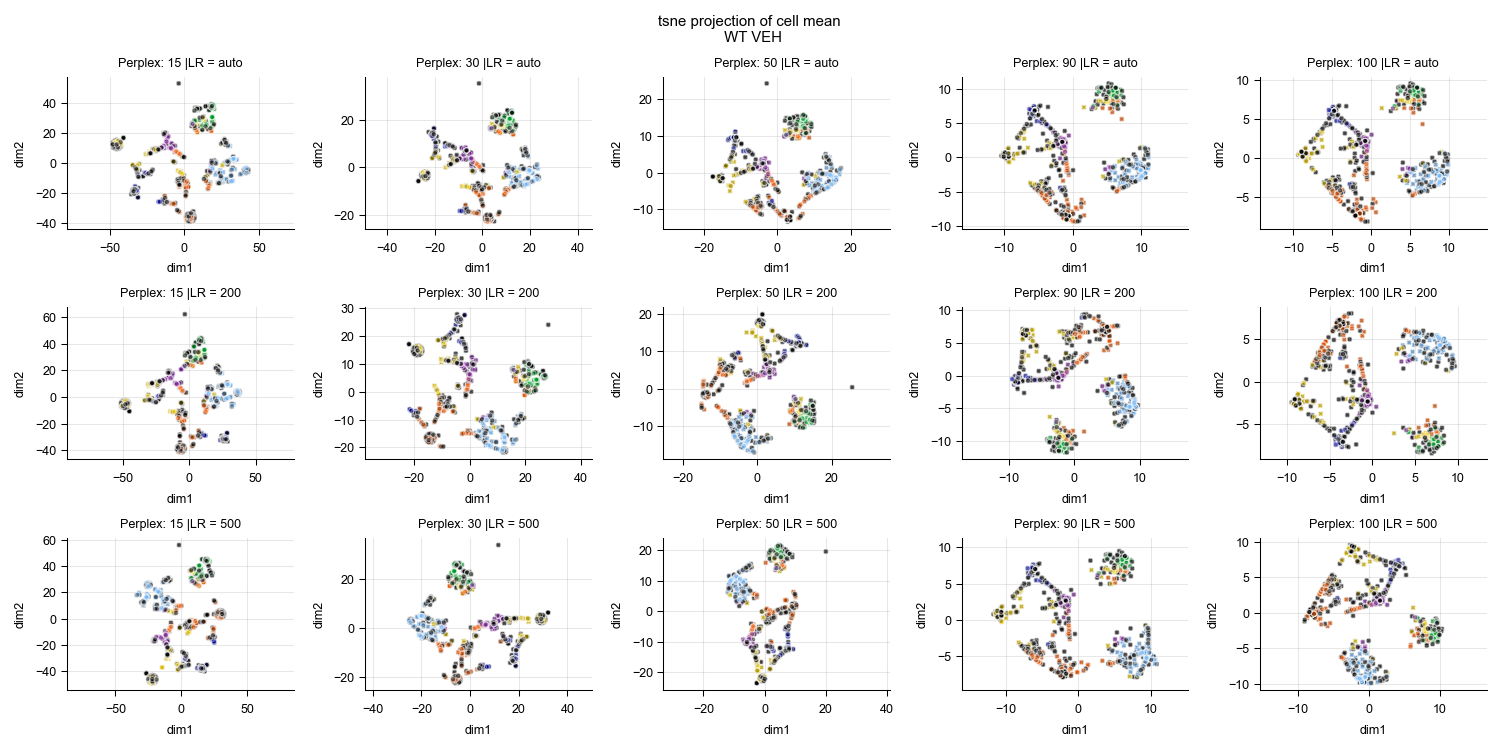

In [39]:
# #ENRICHED: s = 6,alpha = 0.5, legend = make_legend, palette = [stage_palette_dict[x] for x in stage_chrono_order], hue_order =stage_chrono_order,zorder=100 )
alpha = 0.5
s_base = 6

#rows are perplexity
perplexity= [15, 30, 50, 90, 100]
n_cols =len(perplexity) 
#cols are learning rate
learning_rate= ['auto', 200, 500]
n_rows = len(learning_rate)


## PLOTTING- note that paper tSNE is projection of mean activity in stage, colored by ensemble identity

fig, ax_array = plt.subplots(n_rows, n_cols, figsize=(10, 5))
fig.suptitle(f"{method} projection of cell {value_to_project} \n WT VEH")
palette = [stage_palette_dict[x] for x in stage_names]
hue_order = stage_names 
hue_col = 'first_active_stage'

for c, perplexity_val in enumerate(perplexity):
    print(c,perplexity_val)
    for r, lr_val in enumerate(learning_rate):
        print(r,lr_val )
        params = dict(learning_rate = lr_val, perplexity = perplexity_val, random_seed = 42)
        ax_data, _, input_df = get_lowD_matrix_w_ensemble_info(test_df, value_col=value_to_project, method= method, method_params= params, stage_order= stage_names, verbose=False)

        #plot enriched
        ax = ax_array[r,c]
        sns.scatterplot(ax=ax, data=ax_data, x='dim1', y='dim2', hue=hue_col, palette=palette, hue_order=hue_order , s=s_base, alpha=alpha,linewidth=0.5, legend=False, zorder = 100)
         #plot NONenriched
        sns.scatterplot(ax=ax, data=ax_data, x='dim1', y='dim2', marker = 'X', hue=hue_col, palette=['black'], hue_order=['Never'] , s=s_base, alpha=alpha, linewidth=0.35, legend=False, zorder = 0)
        #layout changes
        ax.set_title(f'Perplex: {perplexity_val} |LR = {lr_val}')
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal', adjustable = 'datalim')
fig.tight_layout()

#### NEW Rev- Run FDR on ensembles

In [40]:
#return_FDR_pvalue_df() is called on DF, which sorts values, find crit value, then check pvalue against that critical value
## multiple corrections functions
def return_FDR_pvalue_df(pval_vec_test_input, pvalue_col_name, FDR_alpha_to_use = 0.05):
    """ perform 2step FDR on p-value vector """ 
    #to : given a vector othat inlclues the combined name + pvalue
    #specify what col this pvalue is within

    
    critical_value_at_sorted_index = return_critical_value_vector(FDR_alpha_to_use, len(pval_vec_test_input)) #vector where position k = k * alpha value / len of overall vector
    #important- keep ID of position to merge appropriately 
    if type(pval_vec_test_input) is pd.core.series.Series:
        pvals_sorted = pval_vec_test_input.sort_values()
    else:
        pvals_sorted = pval_vec_test_input.sort_values(by = pvalue_col_name)
    pval_below_crit =  pvals_sorted[pvalue_col_name] <= critical_value_at_sorted_index #bool vec: true if pvalue <= crit value at equivalent index
    print(f"np.sum(pval_below_crit) = {np.sum(pval_below_crit)}")
    print(f"pval_below_crit {pval_below_crit}")
    # find max p val for 2 step
    if np.sum(pval_below_crit) > 0:
            max_p_below_crit_val = np.max(pvals_sorted[pval_below_crit]) #the larges p value that still is below critical value
    else:
            max_p_below_crit_val = pd.Series()
            max_p_below_crit_val[pvalue_col_name] = 0
    
    print(max_p_below_crit_val)
    # print(pvals_sorted[pval_below_crit])

    pval_vec_test_input['pval_below_crit'] =pval_below_crit
    pval_vec_test_input['crit_value'] =critical_value_at_sorted_index
    #given the maximum p value that is still below its corresponding crit value, threshold all pvalues
    pval_vec_test_input['is_pval_sig_fdr'] = pval_vec_test_input[pvalue_col_name] <= max_p_below_crit_val[pvalue_col_name]
    return pval_vec_test_input, pvals_sorted[pval_below_crit]

## minimum viable prod:  return correction col, no critical bvalue
def get_significance_multi_correction(pval_col, correction_type, alpha = 0.05, num_unique_comparisons= None):
    '''  
    inputs:    pval_col: numpy array: 
    '''
    #takes FDR or bonf
    if num_unique_comparisons == None: #set default to len of pval_col
        num_unique_comparisons= len(pval_col)
    #returns series of corrections
    if correction_type == "bonf":
        corrected_col =  pval_col<(alpha/num_unique_comparisons)
    if correction_type == "FDR": # create FDR significance vector
        corrected_col, crit_vals = return_fdr_correction_on_pval_vector(pval_col, alpha)
    return corrected_col

#code for FDR comparison on pvalue vector
# Calculate each individual p-value’s Benjamini-Hochberg critical value, using the formula (i/m)Q, where:
#    # i = the individual p-value’s rank,    # m = total number of tests,    # Q = the false discovery rate (a percentage, chosen by you).
def return_fdr_correction_on_pval_vector(input_pval_vec, alpha = 0.05):
    #inputs- input_pval_vec, numpy vecor 
    pvals_sorted = np.sort(input_pval_vec)
    critical_value_at_sorted_index = return_critical_value_vector(alpha, len(input_pval_vec)) #vector where position k = k * alpha value / len of overall vector
    # for sorted position k, find k*alpha/length(vector) which = factor adjustment that will be MULTIPLIED pvalue
    pval_sig_fdr =  pvals_sorted <= critical_value_at_sorted_index

    # now find largest P(k) such that P(k) < critical value
    if np.sum(pval_sig_fdr) > 0:
        max_p_below_crit_val = np.max(pvals_sorted[pval_sig_fdr]) #the larges p value that still is below critical value
    else:
        max_p_below_crit_val = 0
    #this uses original pvale vec, then thresholds
    is_pval_sig_fdr = input_pval_vec <= max_p_below_crit_val # B-H finds largest K such that P <= K
    #all p values below max_p_below_crit_val is significant
    return is_pval_sig_fdr, critical_value_at_sorted_index

#return the critical value
def return_critical_value_vector(input_alpha, vec_len):
        critical_value_at_sorted_index = input_alpha* (np.arange(1,vec_len+1)/vec_len) #vector where position k = k * alpha value / len of overall vector
        return critical_value_at_sorted_index


In [129]:
# #because I want to keep the crit value associated with the p-value, rather than just the sorted crit value, I input as a series
# input_pval_series = test_df[pval_col_name].copy()
# alpha = 0.05
## functio mockup
def perform_BH_FDR_on_pvalue_series(input_pval_series: pd.Series, 
                                    pval_col_name:str =  "percent_shuffle >= real",
                                    alpha:float = 0.05):
    """ Funciton to take pd.Series with p-values, perform 2-step BH FDR and return corrected significance and associ. crit values used
    returns:
    merged_df: pandas df merging original input series with new FDR info"""
    input_pval_series= input_pval_series.to_frame() #change series to frame to allow adding
    sorted_input_pval_df = input_pval_series.sort_values(by = pval_col_name)
    #get critical value vector
    critical_value_at_sorted_index = return_critical_value_vector(alpha, len(input_pval_series)) #vector where position k = k * alpha value / len of overall vector
    print(f"Finding K for up to {len(input_pval_series)} places, with alpha = {alpha}")
    # add critical value to sorted df
    sorted_input_pval_df['critical_val_at_sort_idx'] = critical_value_at_sorted_index
    sorted_input_pval_df['is_sorted_pval_below_crit_val']=  sorted_input_pval_df.apply(lambda x: x[pval_col_name] <= x['critical_val_at_sort_idx'], axis = 1)

    #if at least 1 p-value is < k, find the following:
    if sorted_input_pval_df['is_sorted_pval_below_crit_val'].sum() > 0:
    
    #find maximum p-value that is less than or equal to K (critical value at its index)
        sorted_pval_below_k_bool =   sorted_input_pval_df['is_sorted_pval_below_crit_val']
        #use boolean to index into sorted array, and get largest p-value 
        max_pval_below_crit_val = sorted_input_pval_df.loc[sorted_pval_below_k_bool, pval_col_name].max()
        #threshold ALL pvalues with largest sub-K p-value:
        sorted_input_pval_df['is_pval_below_max_subK_pval'] = sorted_input_pval_df[pval_col_name] <= max_pval_below_crit_val
    
    else: #else, fill in gaps and set all bool sig below FDr to 0
        print(f" FDR results in 0 p-vals < threshold")
        sorted_input_pval_df['is_pval_below_max_subK_pval'] = False
        max_pval_below_crit_val = np.nan
    print(f"max_pval_below_crit_val = {max_pval_below_crit_val}")

    #after everything, re-join on index with input series
    function_added_cols = ['is_pval_below_max_subK_pval','is_sorted_pval_below_crit_val','critical_val_at_sort_idx']
    merged_df = input_pval_series.merge(sorted_input_pval_df[function_added_cols], left_index = True, right_index = True)
    #record max p value used
    merged_df['max_p_below_k']= max_pval_below_crit_val
    # check that you mantained size of series
    assert sorted_input_pval_df.shape[0] == input_pval_series.shape[0]
    return merged_df



In [130]:
test_df =ensembles_by_datatype['raster'].query(f'geno_day ==  "WT VEH"')
test_df

,task_stage,cell,percentile_95,mean,enriched,percent_shuffle >= real,subject_name,neuron_id,date_made,n_shuffles,data_type,day,geno,geno_day
5478,Early_IA_Correct,cell_1,0.122222,0.025556,False,0.4366,13_4_WT_RS1,13_4_WT_RS1-1,08-Dec-2025,10000,raster,1,WT,WT VEH
5479,Early_IA_Error,cell_1,0.135000,0.125000,False,0.0583,13_4_WT_RS1,13_4_WT_RS1-1,08-Dec-2025,10000,raster,1,WT,WT VEH
5480,Early_RS_Correct,cell_1,0.098333,0.030000,False,0.4848,13_4_WT_RS1,13_4_WT_RS1-1,08-Dec-2025,10000,raster,1,WT,WT VEH
5481,Early_RS_Error,cell_1,0.186667,0.000000,False,1.0000,13_4_WT_RS1,13_4_WT_RS1-1,08-Dec-2025,10000,raster,1,WT,WT VEH
5482,Late_IA,cell_1,0.091333,0.000000,False,1.0000,13_4_WT_RS1,13_4_WT_RS1-1,08-Dec-2025,10000,raster,1,WT,WT VEH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30756,Early_IA_Error,cell_99,0.121750,0.000000,False,1.0000,7_5_WT_RS1,7_5_WT_RS1-99,08-Dec-2025,10000,raster,1,WT,WT VEH
30757,Early_RS_Correct,cell_99,0.115556,0.056667,False,0.1955,7_5_WT_RS1,7_5_WT_RS1-99,08-Dec-2025,10000,raster,1,WT,WT VEH
30758,Early_RS_Error,cell_99,0.115000,0.000000,False,1.0000,7_5_WT_RS1,7_5_WT_RS1-99,08-Dec-2025,10000,raster,1,WT,WT VEH
30759,Late_IA,cell_99,0.083333,0.078000,False,0.0650,7_5_WT_RS1,7_5_WT_RS1-99,08-Dec-2025,10000,raster,1,WT,WT VEH


In [139]:

#iterate using FDR by subject on task stage
all_fdr_pval = []
pval_col_name = "percent_shuffle >= real"
alpha_FDR = 0.10
for s in stage_names:
    
    stage_df = test_df.loc[test_df.task_stage == s,:]
    unique_subj = stage_df.subject_name.unique()
    for subj in unique_subj:

        subj_df = stage_df.loc[stage_df.subject_name == subj,:]
        input_pval_series = subj_df[pval_col_name]
        print(f" {s} - {subj} matrix shape - {input_pval_series.shape}")
        corr_pval = perform_BH_FDR_on_pvalue_series(input_pval_series, pval_col_name = pval_col_name, alpha = alpha_FDR)
        all_fdr_pval.append(corr_pval)

subjXstage_FDR_df = test_df.merge(pd.concat(all_fdr_pval), left_index = True, right_index = True,suffixes = ("", "_fdr"))
subjXstage_FDR_df

 Early_IA_Error - 13_4_WT_RS1 matrix shape - (182,)
Finding K for up to 182 places, with alpha = 0.1
 FDR results in 0 p-vals < threshold
max_pval_below_crit_val = nan
 Early_IA_Error - 14_2_WT_RS1 matrix shape - (166,)
Finding K for up to 166 places, with alpha = 0.1
 FDR results in 0 p-vals < threshold
max_pval_below_crit_val = nan
 Early_IA_Error - 5_3_WT_RS1 matrix shape - (159,)
Finding K for up to 159 places, with alpha = 0.1
max_pval_below_crit_val = 0.0002
 Early_IA_Error - 6_2_WT_RS1 matrix shape - (160,)
Finding K for up to 160 places, with alpha = 0.1
max_pval_below_crit_val = 0.0003
 Early_IA_Error - 7_2_WT_RS1 matrix shape - (81,)
Finding K for up to 81 places, with alpha = 0.1
 FDR results in 0 p-vals < threshold
max_pval_below_crit_val = nan
 Early_IA_Error - 7_4_WT_RS1 matrix shape - (116,)
Finding K for up to 116 places, with alpha = 0.1
 FDR results in 0 p-vals < threshold
max_pval_below_crit_val = nan
 Early_IA_Error - 7_5_WT_RS1 matrix shape - (163,)
Finding K for u

,task_stage,cell,percentile_95,mean,enriched,percent_shuffle >= real,subject_name,neuron_id,date_made,n_shuffles,data_type,day,geno,geno_day,percent_shuffle >= real_fdr,is_pval_below_max_subK_pval,is_sorted_pval_below_crit_val,critical_val_at_sort_idx,max_p_below_k
5478,Early_IA_Correct,cell_1,0.122222,0.025556,False,0.4366,13_4_WT_RS1,13_4_WT_RS1-1,08-Dec-2025,10000,raster,1,WT,WT VEH,0.4366,False,False,0.041209,NaN
5479,Early_IA_Error,cell_1,0.135000,0.125000,False,0.0583,13_4_WT_RS1,13_4_WT_RS1-1,08-Dec-2025,10000,raster,1,WT,WT VEH,0.0583,False,False,0.013187,NaN
5480,Early_RS_Correct,cell_1,0.098333,0.030000,False,0.4848,13_4_WT_RS1,13_4_WT_RS1-1,08-Dec-2025,10000,raster,1,WT,WT VEH,0.4848,False,False,0.031319,NaN
5481,Early_RS_Error,cell_1,0.186667,0.000000,False,1.0000,13_4_WT_RS1,13_4_WT_RS1-1,08-Dec-2025,10000,raster,1,WT,WT VEH,1.0000,False,False,0.031319,NaN
5482,Late_IA,cell_1,0.091333,0.000000,False,1.0000,13_4_WT_RS1,13_4_WT_RS1-1,08-Dec-2025,10000,raster,1,WT,WT VEH,1.0000,False,False,0.066484,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30756,Early_IA_Error,cell_99,0.121750,0.000000,False,1.0000,7_5_WT_RS1,7_5_WT_RS1-99,08-Dec-2025,10000,raster,1,WT,WT VEH,1.0000,False,False,0.100000,0.0004
30757,Early_RS_Correct,cell_99,0.115556,0.056667,False,0.1955,7_5_WT_RS1,7_5_WT_RS1-99,08-Dec-2025,10000,raster,1,WT,WT VEH,0.1955,False,False,0.020245,NaN
30758,Early_RS_Error,cell_99,0.115000,0.000000,False,1.0000,7_5_WT_RS1,7_5_WT_RS1-99,08-Dec-2025,10000,raster,1,WT,WT VEH,1.0000,False,False,0.100000,NaN
30759,Late_IA,cell_99,0.083333,0.078000,False,0.0650,7_5_WT_RS1,7_5_WT_RS1-99,08-Dec-2025,10000,raster,1,WT,WT VEH,0.0650,False,False,0.007362,0.0001


In [140]:
print(f" WT-VEH ensemble enrichment (with raw p-value):")
subjXstage_FDR_df.groupby(by = 'task_stage')['enriched'].value_counts().to_frame()
      


 WT-VEH ensemble enrichment (with raw p-value):


count
task_stage       enriched       
Early_IA_Correct False      1148
                 True        119
Early_IA_Error   False       947
                 True         80
Early_RS_Correct False      1193
                 True         74
Early_RS_Error   False      1192
                 True         75
Late_IA          False      1174
                 True         93
Late_RS          False      1223
                 True         44

In [141]:
print(f" FDR corrected (BH) WT-VEH ensemble enrichment:")
subjXstage_FDR_df.groupby(by = 'task_stage')['is_pval_below_max_subK_pval'].value_counts().to_frame()

 FDR corrected (BH) WT-VEH ensemble enrichment:


count
task_stage       is_pval_below_max_subK_pval       
Early_IA_Correct False                         1260
                 True                             7
Early_IA_Error   False                         1024
                 True                             3
Early_RS_Correct False                         1265
                 True                             2
Early_RS_Error   False                         1267
Late_IA          False                         1261
                 True                             6
Late_RS          False                         1263
                 True                             4

In [142]:
corr_pval

,percent_shuffle >= real,is_pval_below_max_subK_pval,is_sorted_pval_below_crit_val,critical_val_at_sort_idx,max_p_below_k
29626,1.0000,False,False,0.050920,NaN
29633,0.1232,False,False,0.009202,NaN
29640,1.0000,False,False,0.081595,NaN
29647,1.0000,False,False,0.080982,NaN
29654,0.5788,False,False,0.043558,NaN
...,...,...,...,...,...
30732,0.0409,False,False,0.004294,NaN
30739,1.0000,False,False,0.052761,NaN
30746,1.0000,False,False,0.052147,NaN
30753,1.0000,False,False,0.092025,NaN


Text(0.5, 0, '% cells enriched in stage')

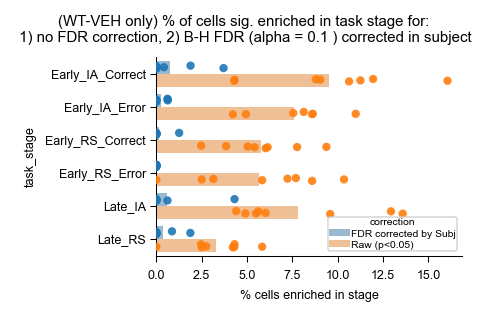

In [145]:
# Reshape to long format for seaborn
plot_df = subjXstage_FDR_df.melt(
    id_vars=['task_stage', 'subject_name'],
    value_vars=['enriched', 'is_pval_below_max_subK_pval'],
    var_name='correction',
    value_name='is_enriched'
)

plot_df['correction'] = plot_df['correction'].map({'enriched': 'Raw (p<0.05)', 'is_pval_below_max_subK_pval': 'FDR corrected by Subj'})

# Per-subject percentages
subj_pct = plot_df.groupby(['task_stage', 'subject_name', 'correction'])['is_enriched'].mean() * 100
subj_pct = subj_pct.reset_index(name='pct_enriched')

# Plot
fig, ax = plt.subplots(figsize=(3, 2), layout = 'constrained')
fig.suptitle(f"(WT-VEH only) % of cells sig. enriched in task stage for:\n 1) no FDR correction, 2) B-H FDR (alpha = {alpha_FDR} ) corrected in subject")
x_val = 'pct_enriched'
y_val = 'task_stage'
sns.barplot(data=subj_pct, x=x_val, y=y_val, hue='correction', ax=ax, alpha=0.5, errorbar=None)
sns.stripplot(data=subj_pct, x=x_val, y=y_val, hue='correction', ax=ax, dodge=True,  alpha=0.9, size=4, legend=False)
ax.set_xlabel('% cells enriched in stage')


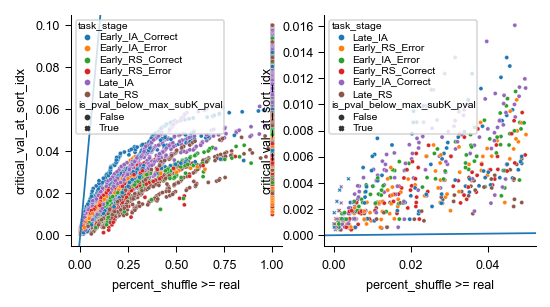

In [144]:
##BH per wikipedia:
#  Geometrically, this corresponds to plotting P ( k ) {\displaystyle P_{(k)}} vs. k (on the y and x axes respectively), 
# drawing the line through the origin with slope α m {\displaystyle {\frac {\alpha }{m}}} ,
#  and declaring discoveries for all points on the left, up to, and including the last point that is not above the line.
##
fix, ax_array = plt.subplots(1,2, figsize = (4,2))
ax = ax_array[0]
sns.scatterplot(ax = ax, data = subjXstage_FDR_df, x = pval_col_name, y = 'critical_val_at_sort_idx', style = 'is_pval_below_max_subK_pval', hue = 'task_stage')
ax.axline((0,0), (0.05, 0.05))
#plot only < 0.05
ax = ax_array[1]
sns.scatterplot(ax = ax, data = subjXstage_FDR_df[subjXstage_FDR_df[pval_col_name] <= 0.05], x = pval_col_name, y = 'critical_val_at_sort_idx', style = 'is_pval_below_max_subK_pval', hue = 'task_stage')
ax.axline((0,0), slope = alpha/len(input_pval_series))

In [48]:
stage_df.neuron_id.nunique()

1267

In [49]:
merged_df.apply(lambda x: x['percent_shuffle >= real']< x['critical_val_at_sort_idx'], axis = 1).sum()

10

In [50]:
merged_df.is_pval_below_max_subK_pval.value_counts()

is_pval_below_max_subK_pval
False    7351
True       11
Name: count, dtype: int64

In [51]:
is_sig_fdr, crit_val =  return_fdr_correction_on_pval_vector(test_df[pval_col_name].values)
test_df.assign(**dict(is_sig_fdr=is_sig_fdr, crit_val = crit_val))

,task_stage,cell,percentile_95,mean,enriched,percent_shuffle >= real,subject_name,neuron_id,date_made,n_shuffles,data_type,day,geno,geno_day,is_sig_fdr,crit_val
5478,Early_IA_Correct,cell_1,0.122222,0.025556,False,0.4366,13_4_WT_RS1,13_4_WT_RS1-1,08-Dec-2025,10000,raster,1,WT,WT VEH,False,0.000007
5479,Early_IA_Error,cell_1,0.135000,0.125000,False,0.0583,13_4_WT_RS1,13_4_WT_RS1-1,08-Dec-2025,10000,raster,1,WT,WT VEH,False,0.000014
5480,Early_RS_Correct,cell_1,0.098333,0.030000,False,0.4848,13_4_WT_RS1,13_4_WT_RS1-1,08-Dec-2025,10000,raster,1,WT,WT VEH,False,0.000020
5481,Early_RS_Error,cell_1,0.186667,0.000000,False,1.0000,13_4_WT_RS1,13_4_WT_RS1-1,08-Dec-2025,10000,raster,1,WT,WT VEH,False,0.000027
5482,Late_IA,cell_1,0.091333,0.000000,False,1.0000,13_4_WT_RS1,13_4_WT_RS1-1,08-Dec-2025,10000,raster,1,WT,WT VEH,False,0.000034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30756,Early_IA_Error,cell_99,0.121750,0.000000,False,1.0000,7_5_WT_RS1,7_5_WT_RS1-99,08-Dec-2025,10000,raster,1,WT,WT VEH,False,0.049973
30757,Early_RS_Correct,cell_99,0.115556,0.056667,False,0.1955,7_5_WT_RS1,7_5_WT_RS1-99,08-Dec-2025,10000,raster,1,WT,WT VEH,False,0.049980
30758,Early_RS_Error,cell_99,0.115000,0.000000,False,1.0000,7_5_WT_RS1,7_5_WT_RS1-99,08-Dec-2025,10000,raster,1,WT,WT VEH,False,0.049986
30759,Late_IA,cell_99,0.083333,0.078000,False,0.0650,7_5_WT_RS1,7_5_WT_RS1-99,08-Dec-2025,10000,raster,1,WT,WT VEH,False,0.049993
